# Machine LearningAfter Bond Specific orthogonal TB

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
import copy
from importlib.machinery import SourceFileLoader
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from tqdm.notebook import tqdm_notebook
import re

In [2]:
# Original DFT Data
BS = StructSummaryParser().BriefSummary

In [3]:
# the moments I calculated in some other ocasion - NSC canonical tight binding model
BondSpecific = pd.read_pickle('CANONICALTB_RESULTS_NSC.pkl')

BondSpecific.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
# Atomic Averages:

BondSpecific.dropna(how='any',inplace=True)

M = BondSpecific['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BondSpecific['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BondSpecific['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BondSpecific['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BondSpecific['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BondSpecific['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
BOP_atom_average = pd.concat([M, S, AN, BN, Ainf, Binf], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)
BOP['NSC_U_bind'] = BondSpecific['NSC_U_bind'].map(float)

del M, S, Binf, Ainf, AN, BN, BondSpecific, BOP_atom_average # now I donnt need any more individual columns

# Some Machine Learning

In [4]:
from seaborn import heatmap
from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt
plt.style.use('seaborn')
plt.rc('figure', figsize=(20,10))
plt.rc('legend',fontsize=20)
plt.rc('axes',labelsize=36)
plt.rc('xtick',labelsize=28)
plt.rc('ytick',labelsize=28)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.pipeline import Pipeline
import sklearn

# Targets


In [6]:
from BopFoxFeaturizer.Featurizer import Featurizer

In [7]:
groundstates = ground_state_energies = {'Re_pv':-12.44533, 'Ni_pv':-5.726500, 'Al':-3.745590, 'Co':-7.107694, 'W_pv':-12.960454,'':0}
featurizer = Featurizer(BS)
BS['EF'] = featurizer.get_formation_energy(groundstates)
BS = BS.dropna()

I am not actually using this ?

In [8]:
def getfloat(s):
    try:
        return float(s)
    except Exception as E:
        return np.NaN

BS['B0']=BS['B0'].map(getfloat)

In [9]:
DATA = BOP.copy()
DATA[['B0','V0','EF']]=BS[['B0','V0','EF']]

In [10]:
Original = pd.read_pickle('data_complete_features.pkl')
Original['B0']=Original['B0'].map(getfloat)
Original['V0']=Original['V0'].map(getfloat)

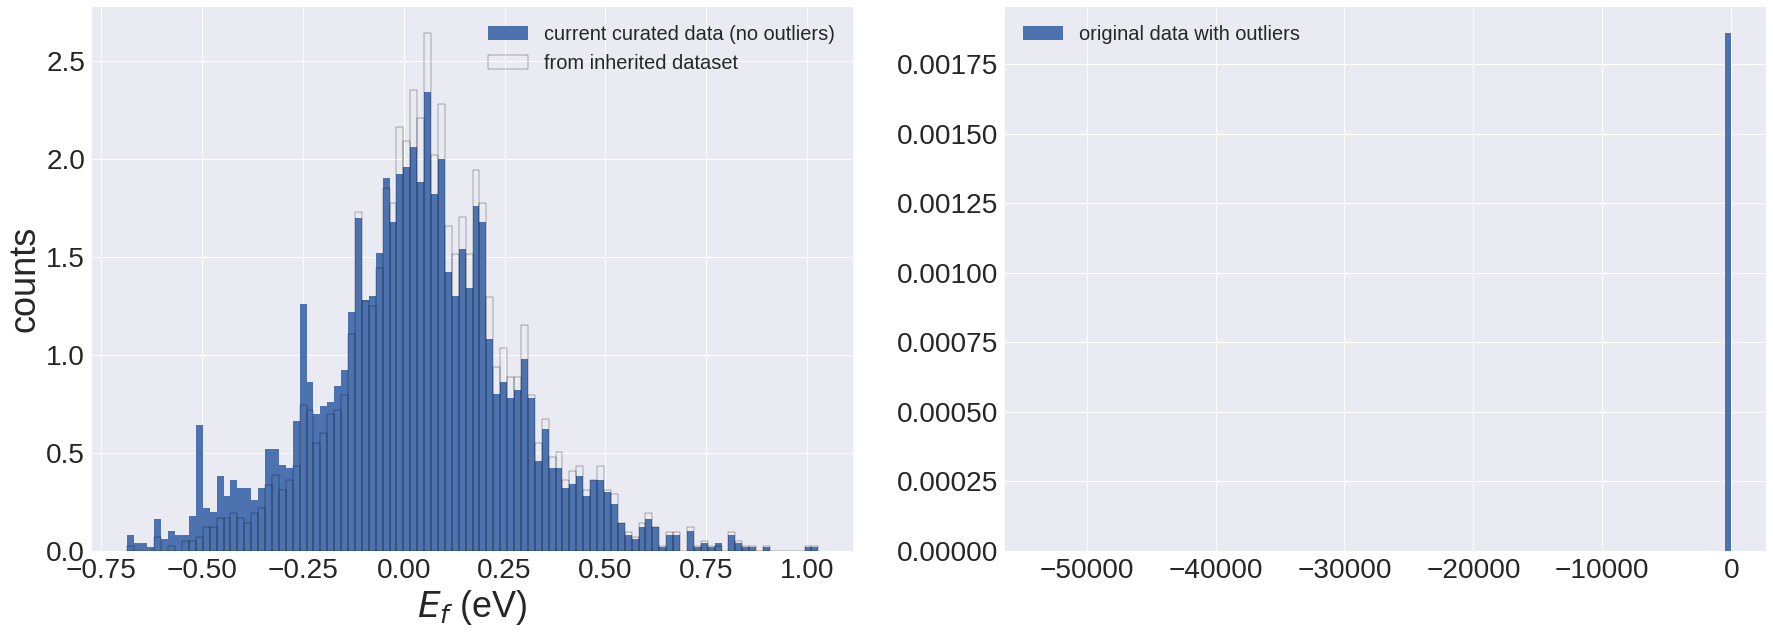

In [11]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS[BS['EF']>-10][BS['EF']<10]['EF'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h2=Original['E_f'].hist(bins=100,fill=None, density=True, ax = ax[0], label='from inherited dataset')
ax[0].legend()
ax[0].set_xlabel('$E_f$ (eV)')
ax[0].set_ylabel('counts')
h3=BS['EF'].hist(bins=100, fill='k', ax=ax[1], density=True, label='original data with outliers')
l = ax[1].legend()

In [12]:
DATA = DATA[DATA['EF']>-10][DATA['EF']<10]

In [13]:
DATA = DATA[ DATA['B0']<600 ]

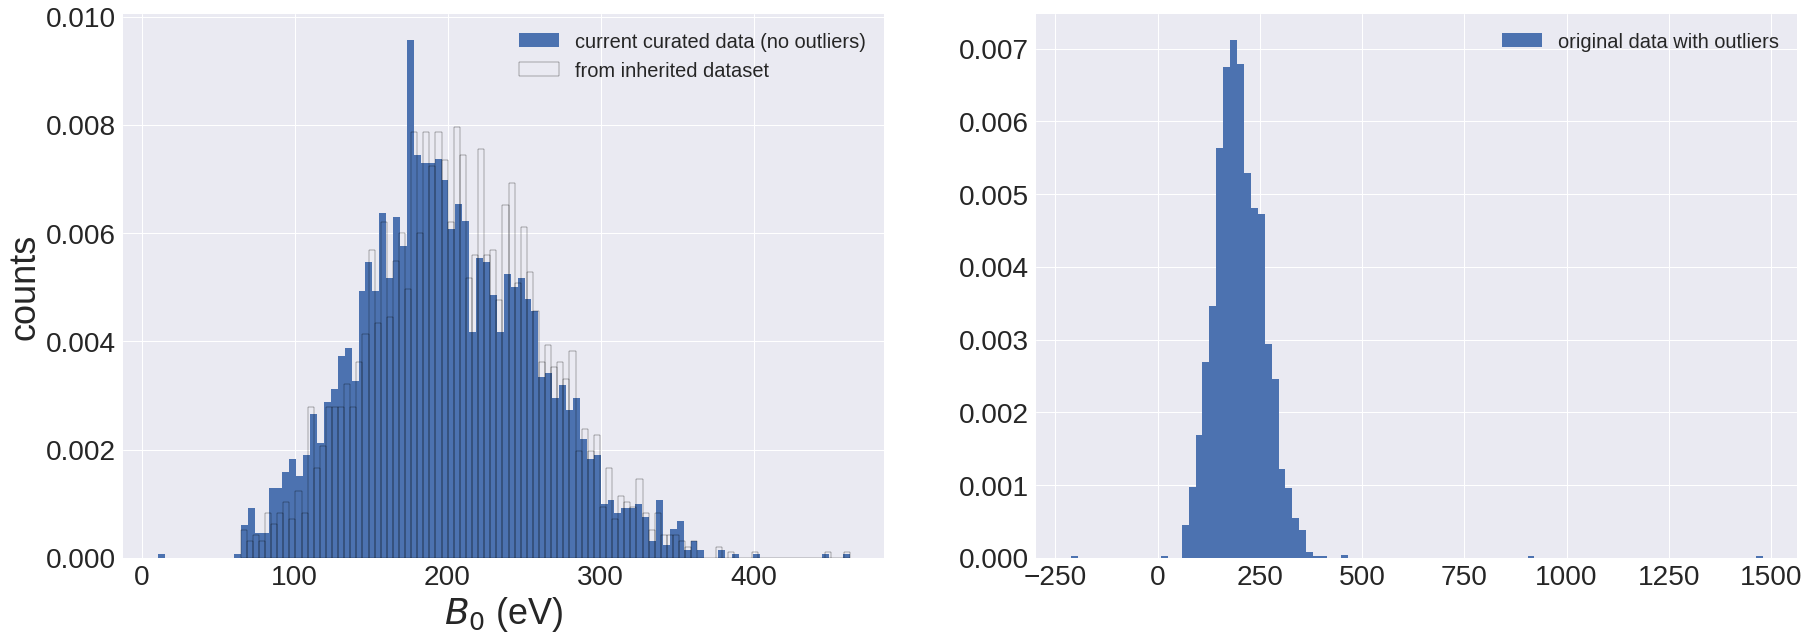

In [14]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS[BS['B0']<600][BS['B0']>0]['B0'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h2=Original['B0'].hist(bins=100,fill=None, density=True, ax = ax[0], label='from inherited dataset')
ax[0].legend()
ax[0].set_xlabel('$B_0$ (eV)')
ax[0].set_ylabel('counts')
h3=BS['B0'].hist(bins=100, fill='k', ax=ax[1], density=True, label='original data with outliers')
l = ax[1].legend()

In [15]:
DATA['B0']=DATA[DATA['B0']<600][DATA['B0']>0]['B0']

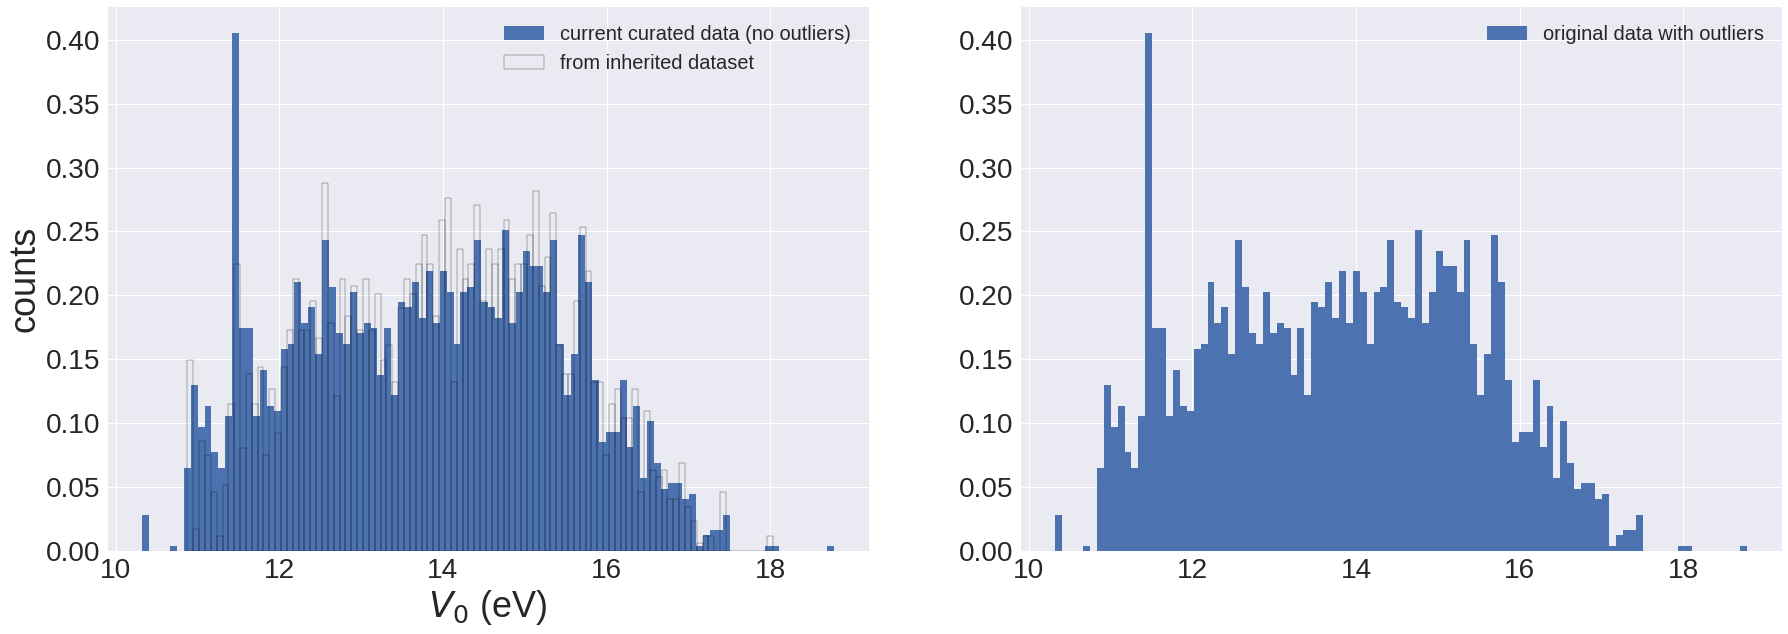

In [16]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS['V0'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h2=Original['V0'].hist(bins=100,fill=None, density=True, ax = ax[0], label='from inherited dataset')
ax[0].legend()
ax[0].set_xlabel('$V_0$ (eV)')
ax[0].set_ylabel('counts')
h3=BS['V0'].hist(bins=100, fill='k', ax=ax[1], density=True, label='original data with outliers')
l = ax[1].legend()

## no filter needed.

```python
DATA=DATA[DATA['NSC_moments_1']<1e4]
DATA.shape
DATA=DATA[abs(DATA['NSC_moments_2'])<15e4]
DATA.shape
DATA[abs(DATA['NSC_moments_3'])<8e7]['NSC_moments_3'].hist(bins=100)
DATA[abs(DATA['NSC_moments_3'])<8e7]['NSC_moments_3'].
DATA=DATA[abs(DATA['NSC_moments_4'])<1.5e5]
DATA[abs(DATA['NSC_moments_4'])<1.5e5]['NSC_moments_4'].hist(bins=100)
```

## Brute Force features and target

In [17]:
X = DATA.drop(columns=['EF', 'B0','V0'])
Y = DATA['EF']

# Histograms of features

Are there more outliers ?

In [18]:
allcolumns = DATA.columns.drop(['B0', 'V0'])
columns = DATA.columns.drop(['B0', 'V0','EF'])

feature_titles = [ s.replace('NSC_','') for s in allcolumns ]
feature_titles = [s.replace('moments_','m_{') for s in feature_titles]
feature_titles = [s.replace('SIGMA_','\\sigma^{(') for s in feature_titles]
feature_titles = [s.replace('an_','a^{(') for s in feature_titles]
feature_titles = [s.replace('bn_','b^{(') for s in feature_titles]
feature_titles = [s.replace('Ainf_0','a^{\infty}') for s in feature_titles]
feature_titles = [s.replace('Binf_0','b^{\infty}') for s in feature_titles]
feature_titles = [s.replace('U_bind','U_{bind}') for s in feature_titles]
feature_titles = [s.replace('EF','E_F') for s in feature_titles]

for s, feature in enumerate(feature_titles):
    if '{(' in feature and ')}' not in feature:
        feature_titles[s] += ')}'
    if '{' in feature and '}' not in feature:
        feature_titles[s] += '}'
    feature_titles[s] = feature_titles[s].replace('{{','{')
    feature_titles[s] = feature_titles[s].replace('}}','}')
    feature_titles[s] = '$'+feature_titles[s]+'$'


feature_titles = pd.Series(feature_titles, index=allcolumns)

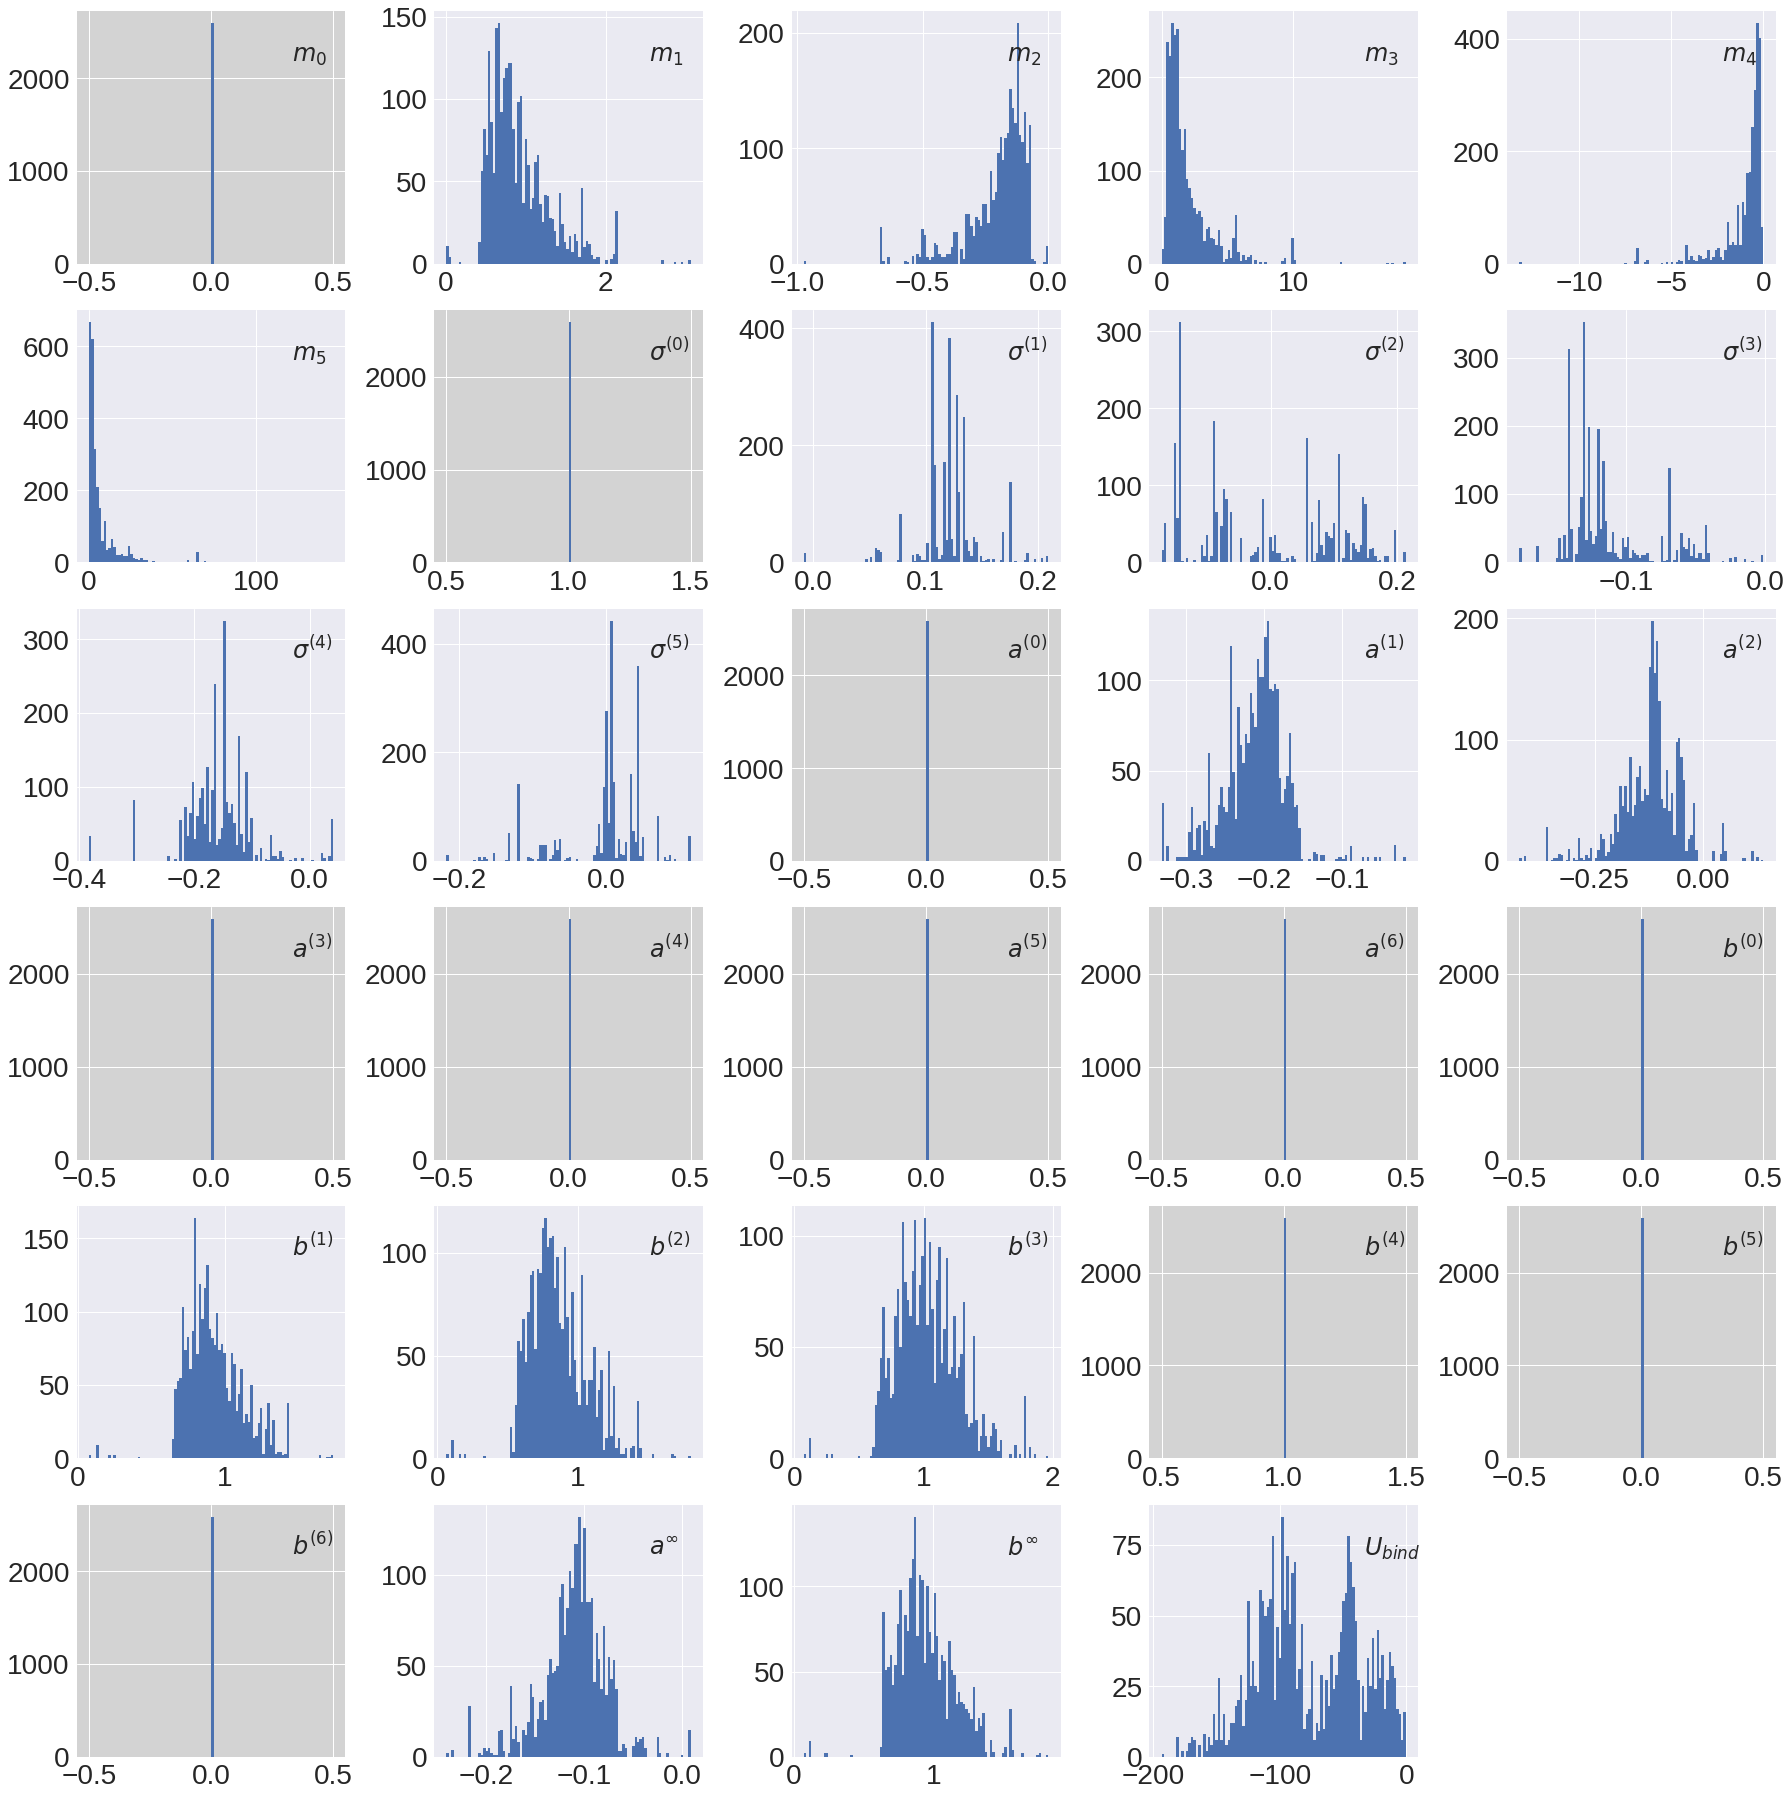

In [23]:
ax=[]
feature = []
fig = plt.figure(figsize=(25, 25))
for c, col in enumerate(columns):
    ax.append( fig.add_subplot( len(columns)/5+1, 5, c+1 ) )
    bins = ax[-1].hist(DATA[col], bins=100)
    
    if sum( bins[0]>0 ) > 1:
        feature.append(col)
    else:
        ax[-1].set_facecolor('lightgray')

for i,axis in enumerate(ax):
    axis.text(0.8, 0.8,feature_titles[i], fontsize=24 , transform=axis.transAxes)
#    axis.set_xlabel(feature_titles[i], fontsize=24)
    
fig.tight_layout()
    
    

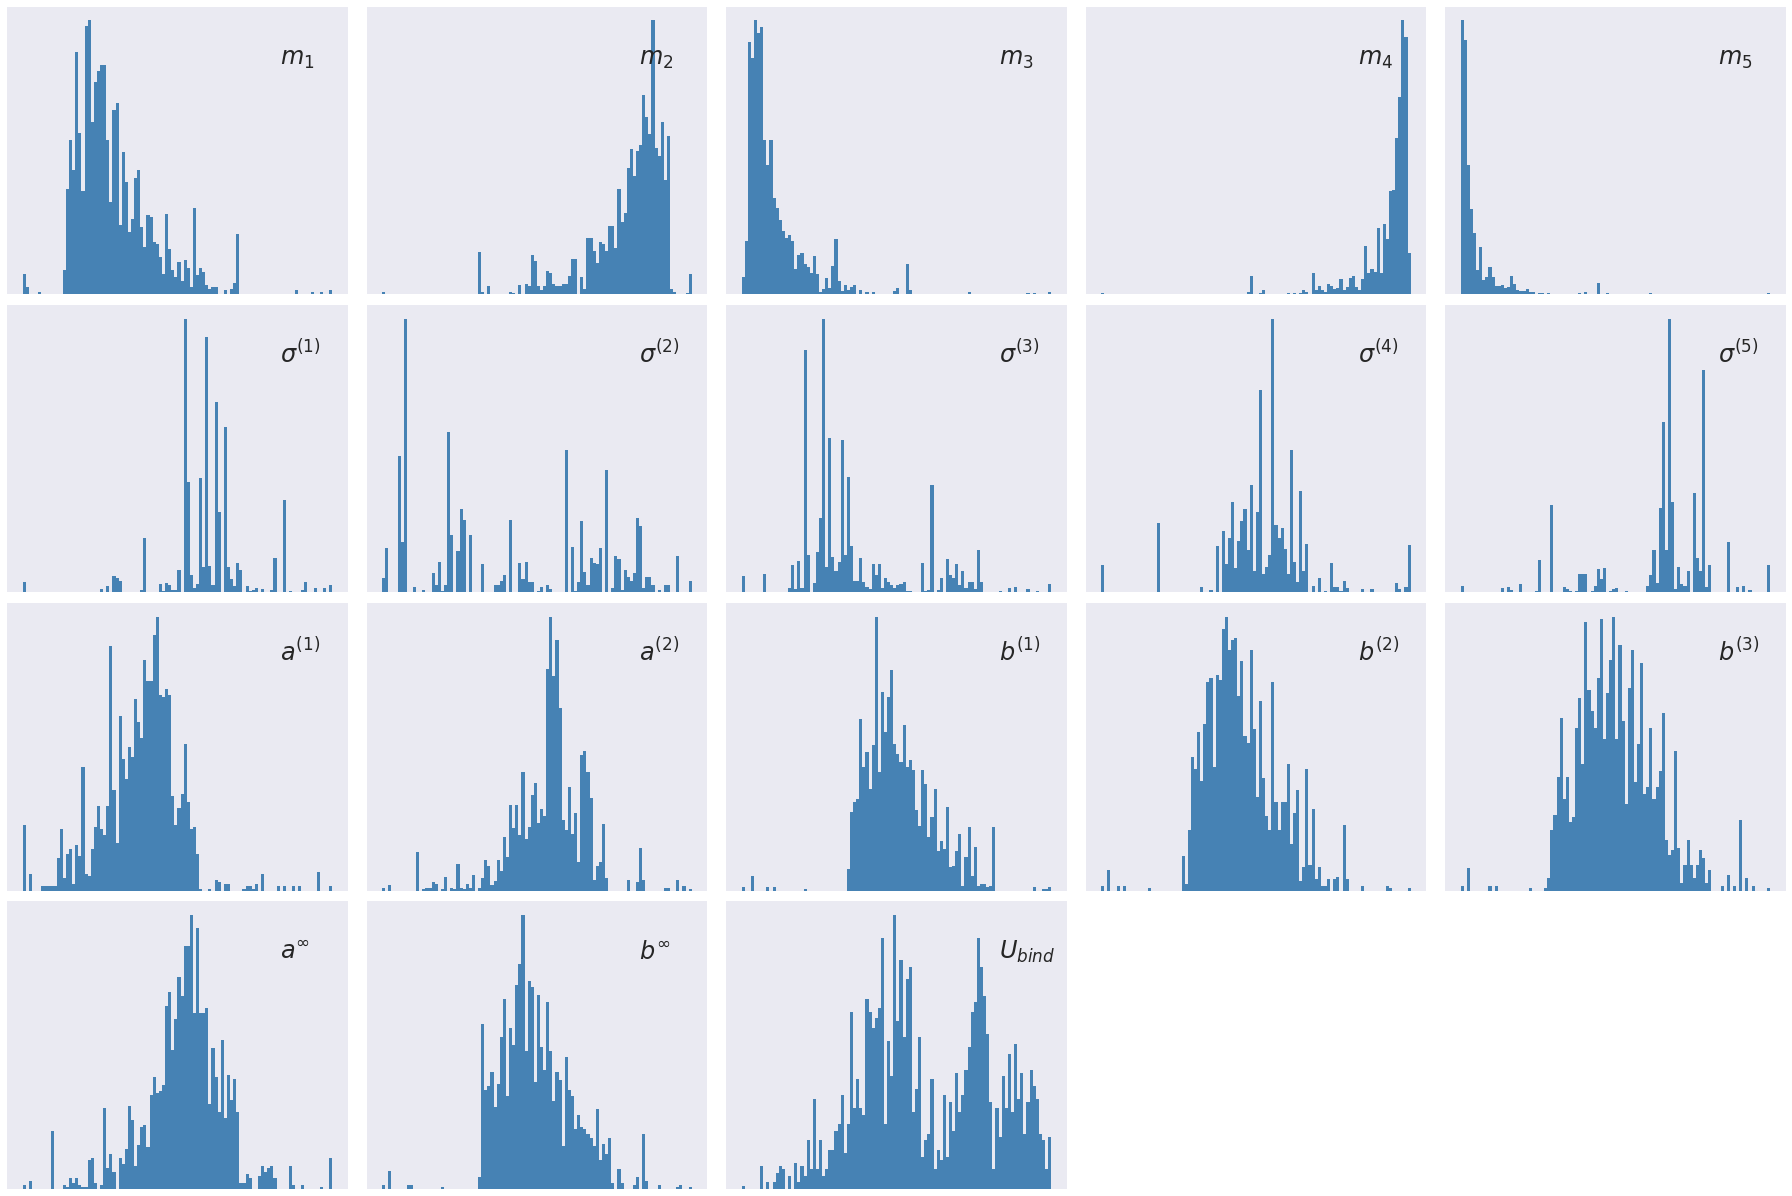

In [26]:
axg = []
fig = plt.figure(figsize=(25,25))
# remember feature_titles
a = 0
feature = []
for c, col in enumerate(columns):
    
    bins, edges = np.histogram(DATA[col], bins=100, density=True)
    # bins = plt.hist(DATA[col], bins=100)
    
    if sum( bins > 0 ) > 1:
        axg.append( fig.add_subplot( len(columns)/5+1, 5, a+1 ) ) 
        a+=1
        axg[-1].bar(edges[:-1], bins, color='steelblue',width=np.diff(edges))
        axg[-1].text(0.8, 0.8, feature_titles.iloc[c], fontsize=24 , transform=axg[-1].transAxes)
#        plt.xlabel(feature_titles[col],y=0.8 )
        axg[-1].set_yticks([])
        axg[-1].set_xticks([])
        feature.append(col)
        
           
fig.tight_layout()

Can somewhat classify the structures from the moments?

# Classification and weighting

In [27]:
Target_Class = DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0])

Class_Names = np.unique(Target_Class)

In [28]:
with open('structures/binary/list.bcc', 'r') as f:
    listbcc = f.readlines()[0].strip().split(' ')

listbcc = ' '.join([re.sub('-.*','',s) for s in listbcc])

with open('structures/binary/list.fcc', 'r') as f:
    listfcc = f.readlines()[0].strip().split(' ')

listfcc = ' '.join([re.sub('-.*','',s) for s in listfcc])

with open('structures/binary/list.hcp', 'r') as f:
    listhcp = f.readlines()[0].strip().split(' ')

listhcp = ' '.join ([re.sub('-.*','',s) for s in listhcp])

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)

Target_Class[Target_Class.map(lambda s: s in listhcp)]='hcp'
Target_Class[Target_Class.map(lambda s: s in listfcc)]='fcc'
Target_Class[Target_Class.map(lambda s: s in listbcc)]='bcc'

Target_Class[DATA.index.str.contains('SQS-fcc')] = 'fcc'
Target_Class[DATA.index.str.contains('SQS-L12')] = 'fcc'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'


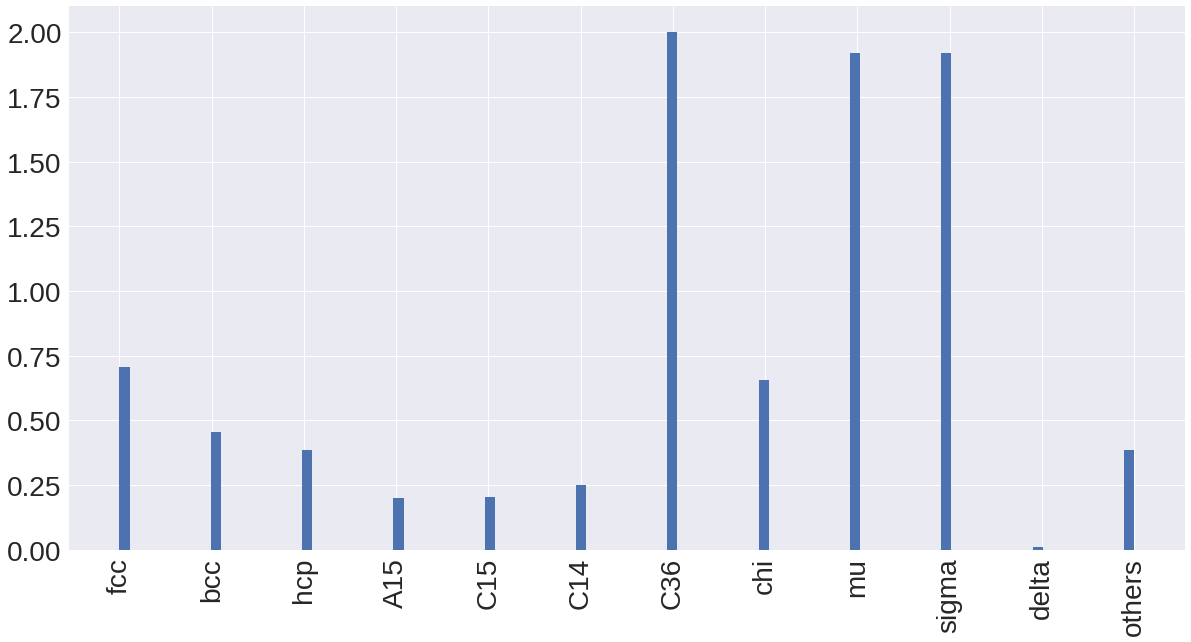

In [29]:
plt.hist(Target_Class, bins=100, density = True)
xticks = plt.xticks(rotation=90)

as we see here, the dataset is quite vadly classified, this will lead to wrong results when I try to regress A15 properties using the rest of the dataset. ths classes should be taken into account and give the weights to the regressors

In [30]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

## Some kind of structure map

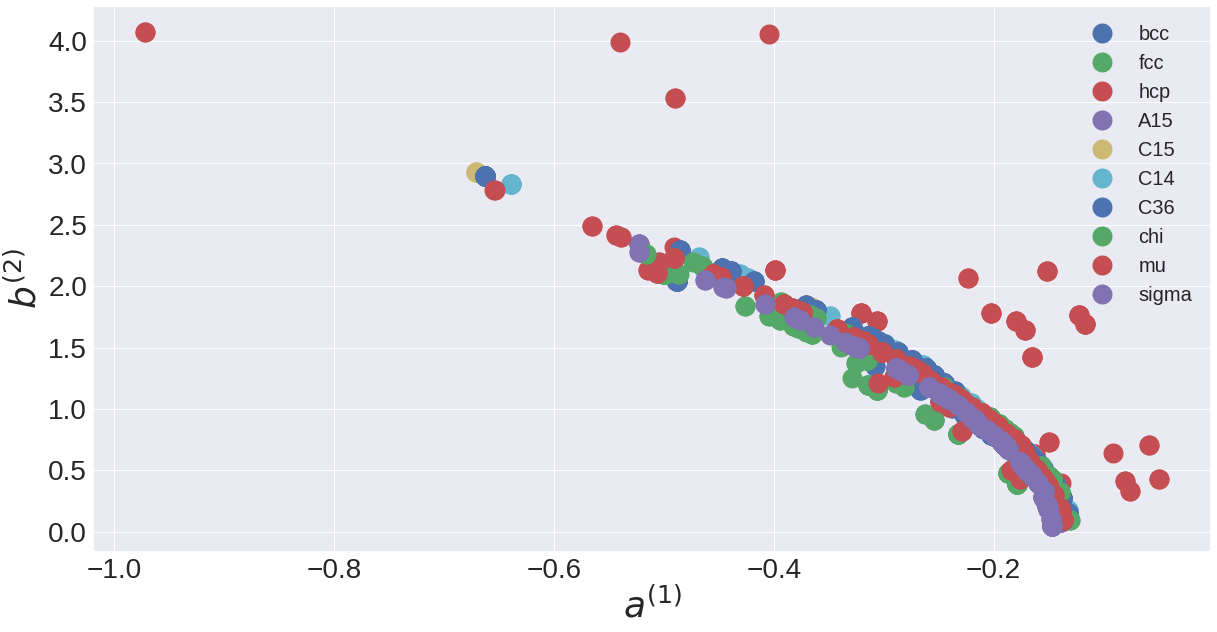

In [31]:
fig = plt.figure(figsize=(20, 10))
class_of_interest = ['bcc','fcc','hcp','A15','C15','C14','C36','chi','mu','sigma']
for i, clase in enumerate(class_of_interest):
    A1 = DATA['NSC_moments_2'][Classes['Class']==clase]
    B2 = np.sqrt( 
        DATA['NSC_moments_3'][Classes['Class']==clase] -
        DATA['NSC_moments_2'][Classes['Class']==clase]**2 -1
    )
    plt.plot(A1,B2, 'o', ms=20, label=clase)
plt.xlabel('$a^{(1)}$')
plt.ylabel('$b^{(2)}$')
#plt.xticks([])
#plt.yticks([])
plt.legend()
    
    

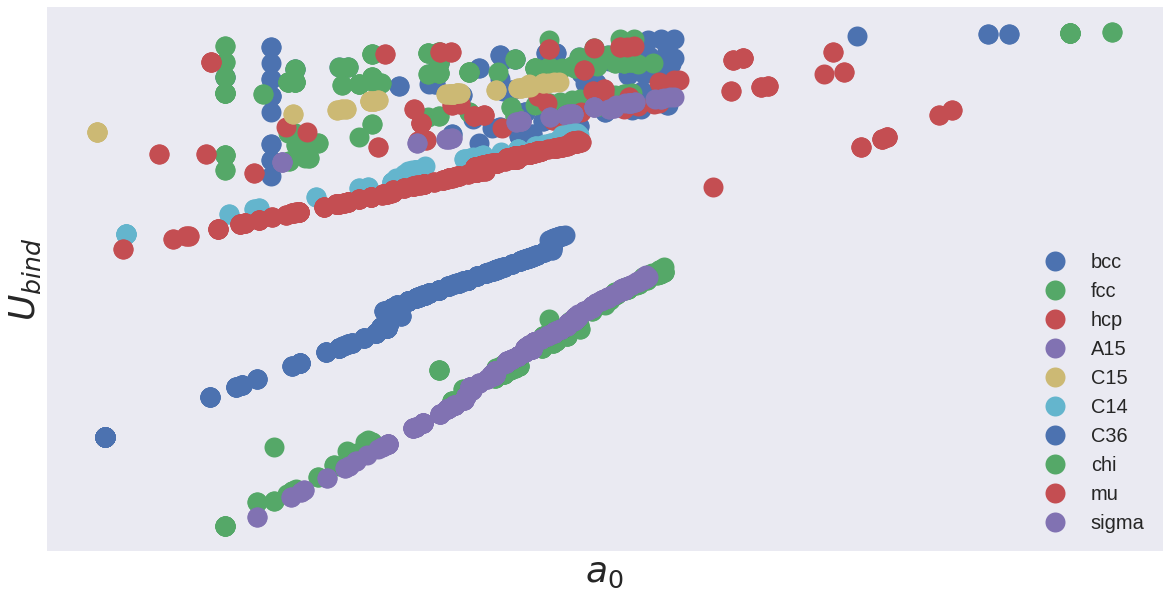

In [32]:
fig = plt.figure(figsize=(20, 10))
class_of_interest = ['bcc','fcc','hcp','A15','C15','C14','C36','chi','mu','sigma']
for i, clase in enumerate(class_of_interest):
    pltX = DATA['NSC_an_1'][Classes['Class']==clase]
    pltY = DATA['NSC_U_bind'][Classes['Class']==clase]
    plt.plot(pltX,pltY, 'o', ms=20, label=clase)
plt.xlabel('$a_0$')
plt.ylabel('$U_{bind}$')
plt.xticks([])
plt.yticks([])
plt.legend()

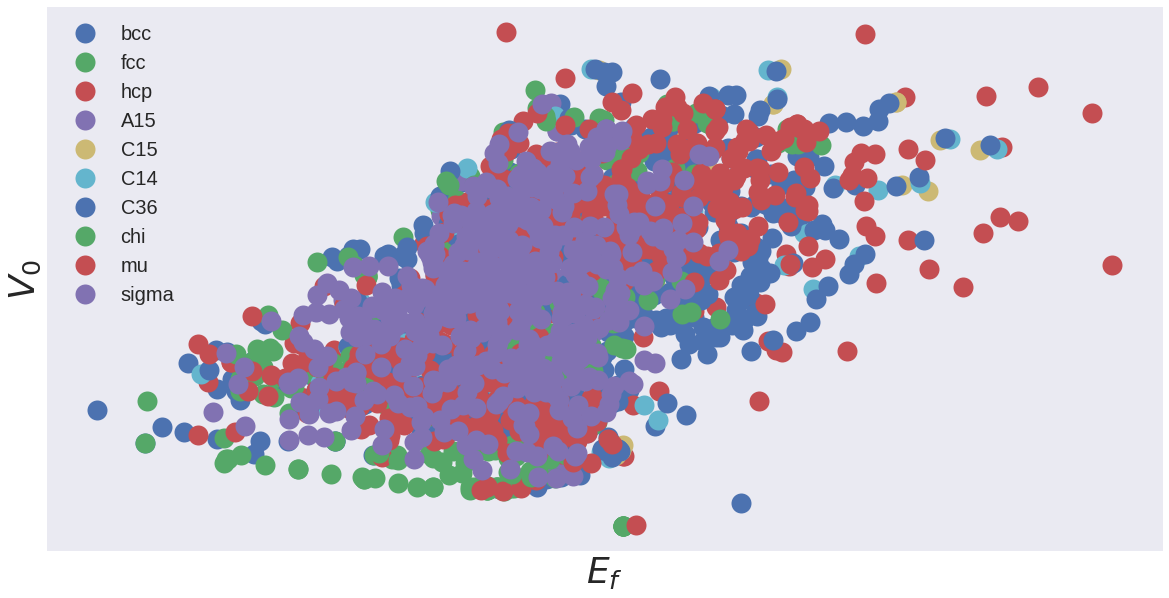

In [33]:
fig = plt.figure(figsize=(20, 10))
class_of_interest = ['bcc','fcc','hcp','A15','C15','C14','C36','chi','mu','sigma']
for i, clase in enumerate(class_of_interest):
    pltX = DATA['EF'][Classes['Class']==clase]
    pltY = DATA['V0'][Classes['Class']==clase]
    plt.plot(pltX,pltY, 'o', ms=20, label=clase)
plt.xlabel('$E_f$')
plt.ylabel('$V_0$')
plt.xticks([])
plt.yticks([])
plt.legend()

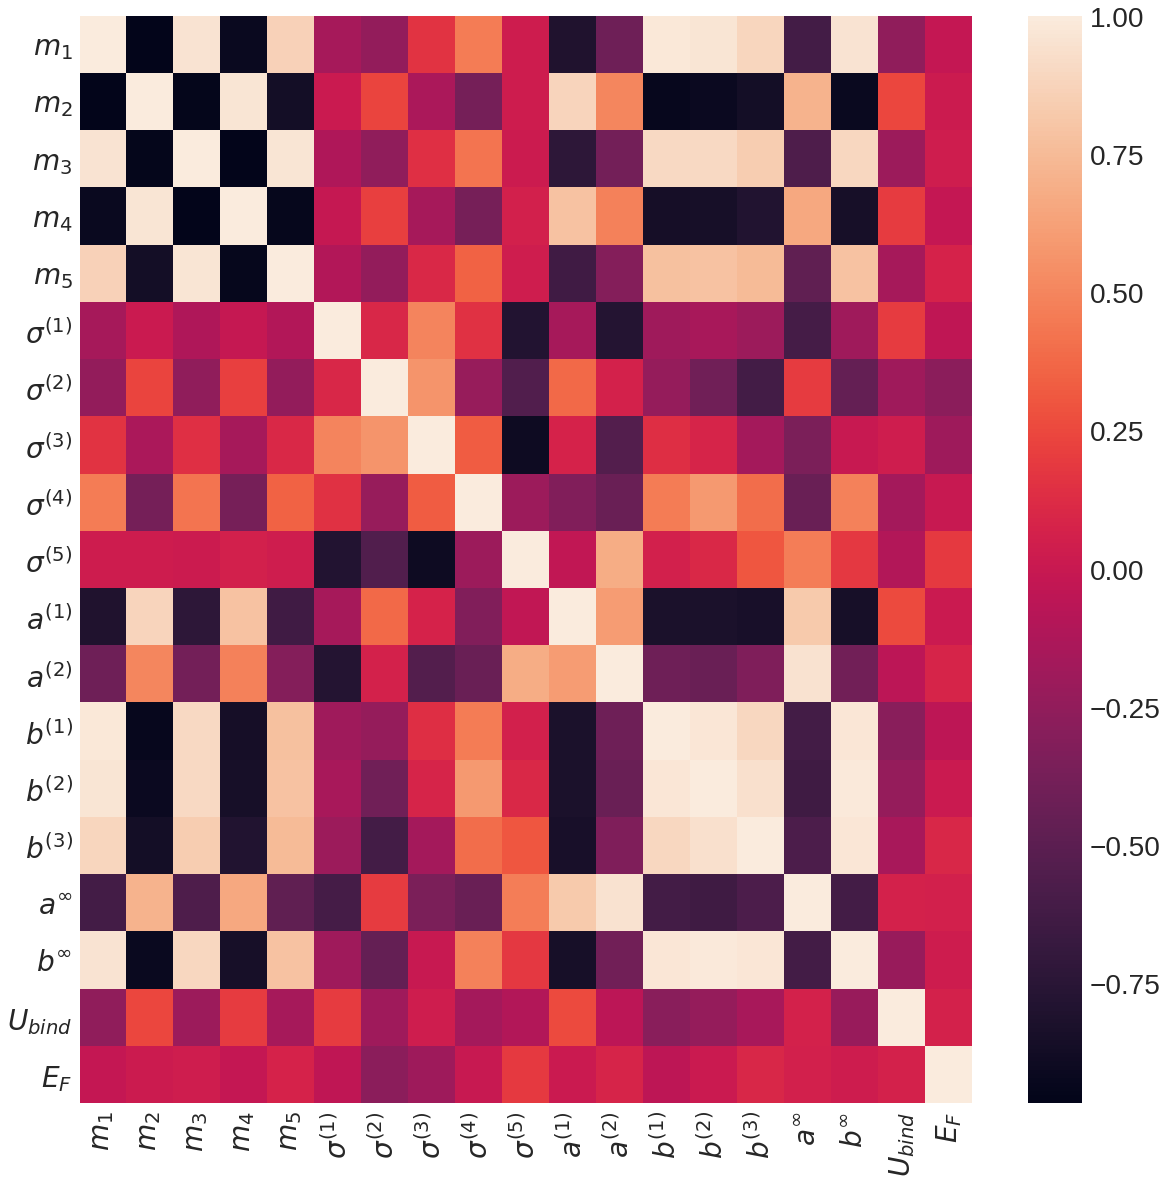

In [34]:
CORRS = DATA[feature+['EF']].corr()
CORRS.dropna(how='all',inplace=True)
CORRS.dropna(inplace=True, axis=1)
ax = plt.figure(figsize=(20,20)).add_axes()
HM = heatmap(CORRS, ax=ax)
labels = CORRS.columns #[s.get_text()  for s in HM.get_yticklabels()] 
ticklabels = [feature_titles[s] for s in labels]
xlabels = HM.set_yticklabels(ticklabels)
ylabels = HM.set_xticklabels(ticklabels)

#corrs_titles = [ s.replace('NSC_','') for s in columns ]
#corrs_titles = [s.replace('moments_','m_') for s in corrs_titles]
#corrs_titles = [s.replace('SIGMA_','\\sigma^{(') for s in corrs_titles]
#corrs_titles = [s.replace('an_','a^{(') for s in corrs_titles]
#corrs_titles = [s.replace('bn_','b^{(') for s in corrs_titles]
#corrs_titles = [s.replace('Ainf_0','a^{\infty}') for s in corrs_titles]
#corrs_titles = [s.replace('Binf_0','b^{\infty}') for s in corrs_titles]
#corrs_titles = [s.replace('U_bind','U_{bind}') for s in corrs_titles]
#
#for s, feat in enumerate(corrs_titles):
#    if '{(' in feat and ')}' not in feat:
#        corrs_titles[s] += ')}'

#ticks = HM.get_xticks()
#HM.set_xticks(ticks, corrs_titles)


I remove this because the scatterplot on so many features is really big and hard to visualize
```python
scatterplot = pd.plotting.scatter_matrix(DATA[feature],figsize=(30,30), diagonal='kde')
for a in range(scatterplot.shape[0]):
#    scatterplot[0,a].set_xlabel(axis.get_xlabel(), rotation=45) #,xy=(-1,0), xycoords='offset') 
    scatterplot[a,0].set_ylabel(scatterplot[a,0].get_ylabel(), rotation=30) 
    scatterplot[-1,a].set_xlabel(scatterplot[a,0].get_xlabel(), rotation=30)
plt.gcf().tight_layout()
```

# Test with Random Forest Regressor

In [35]:
CORRS['EF'][CORRS['EF']<1].index.values

array(['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4',
       'NSC_moments_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3',
       'NSC_SIGMA_4', 'NSC_SIGMA_5', 'NSC_an_1', 'NSC_an_2', 'NSC_bn_1',
       'NSC_bn_2', 'NSC_bn_3', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind'],
      dtype=object)

In [36]:
CORRS['EF'][CORRS['EF']<1].index.values

array(['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4',
       'NSC_moments_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3',
       'NSC_SIGMA_4', 'NSC_SIGMA_5', 'NSC_an_1', 'NSC_an_2', 'NSC_bn_1',
       'NSC_bn_2', 'NSC_bn_3', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind'],
      dtype=object)

In [37]:
model1 = Pipeline([
    ('imputer', SimpleImputer()), # For the failed structures
    ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))
])

In [38]:
model1.fit(X,Y)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))])

In [39]:
Predict = model1.predict(X)
rmse_full = mean_squared_error(DATA['EF'], Predict,squared=False)

In [40]:
rmse_full

0.07865449706487238

some test-train split

In [41]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, random_state = 123496)

model1.fit(Xtrain, Ytrain)

Predict_Train = model1.predict(Xtrain)

Predict_Test = model1.predict(Xtest)

rmsetrain = mean_squared_error(Ytrain, Predict_Train,squared=False)
rmsetest = mean_squared_error(Ytest, Predict_Test,squared=False)

rmsetrain

rmsetest

canonical_global_rmse =  [('full', rmse_full), ('train', rmsetrain), ('test', rmsetest)]

%store canonical_global_rmse

Stored 'canonical_global_rmse' (list)


[Text(0, 0, '$\\sigma^{(2)}$'),
 Text(0, 1, '$a^{(2)}$'),
 Text(0, 2, '$U_{bind}$'),
 Text(0, 3, '$b^{(3)}$'),
 Text(0, 4, '$a^{(1)}$'),
 Text(0, 5, '$a^{\\infty}$'),
 Text(0, 6, '$b^{(2)}$'),
 Text(0, 7, '$m_{2}$'),
 Text(0, 8, '$b^{(1)}$'),
 Text(0, 9, '$m_{4}$')]

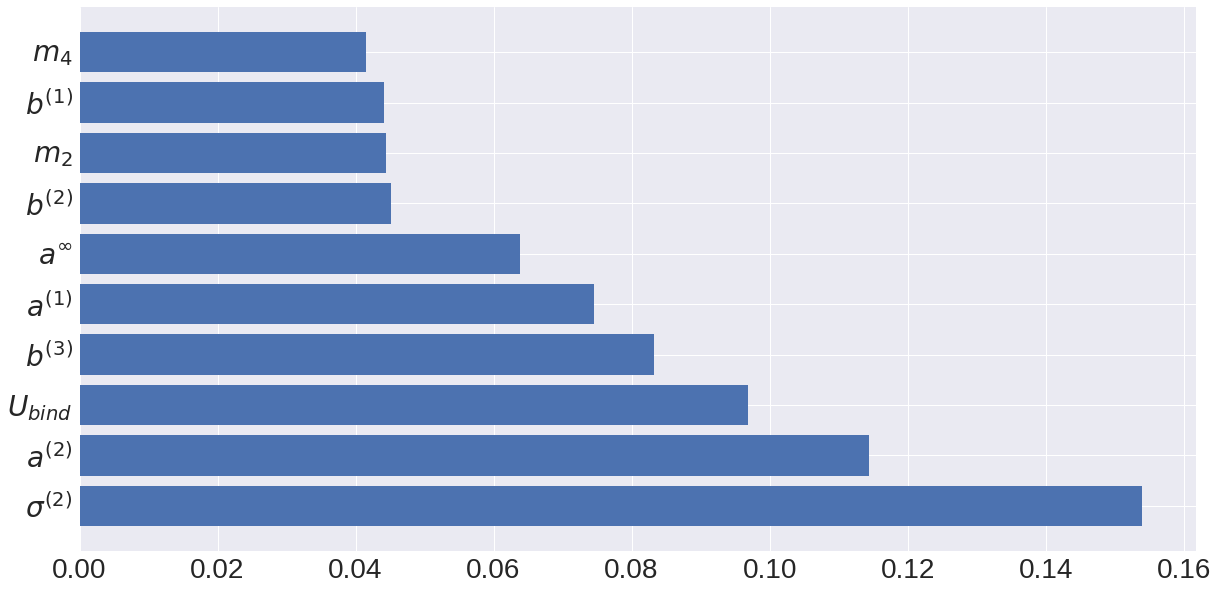

In [42]:
features_with_importances = pd.DataFrame({'features':X.columns, 'importancies':model1['model'].feature_importances_}).sort_values(by='importancies', ascending=False)
plt.barh(features_with_importances[:10]['features'], features_with_importances[:10]['importancies'])
plt.gca().set_yticklabels(feature_titles[features_with_importances[:10]['features']].values)

Fit using sample weights

In [43]:
model1_sample_wights = copy.deepcopy(model1)

In [44]:
model1_sample_wights.fit(X,Y, model__sample_weight=Classes['Weights'])

Pipeline(steps=[('imputer', SimpleImputer()),
                ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))])

In [45]:
Predict_weights = model1_sample_wights.predict(X)

[Text(0, 0, '$U_{bind}$'),
 Text(0, 1, '$\\sigma^{(2)}$'),
 Text(0, 2, '$b^{(3)}$'),
 Text(0, 3, '$a^{(2)}$'),
 Text(0, 4, '$a^{\\infty}$'),
 Text(0, 5, '$a^{(1)}$'),
 Text(0, 6, '$\\sigma^{(4)}$'),
 Text(0, 7, '$b^{(2)}$'),
 Text(0, 8, '$b^{(1)}$'),
 Text(0, 9, '$b^{\\infty}$')]

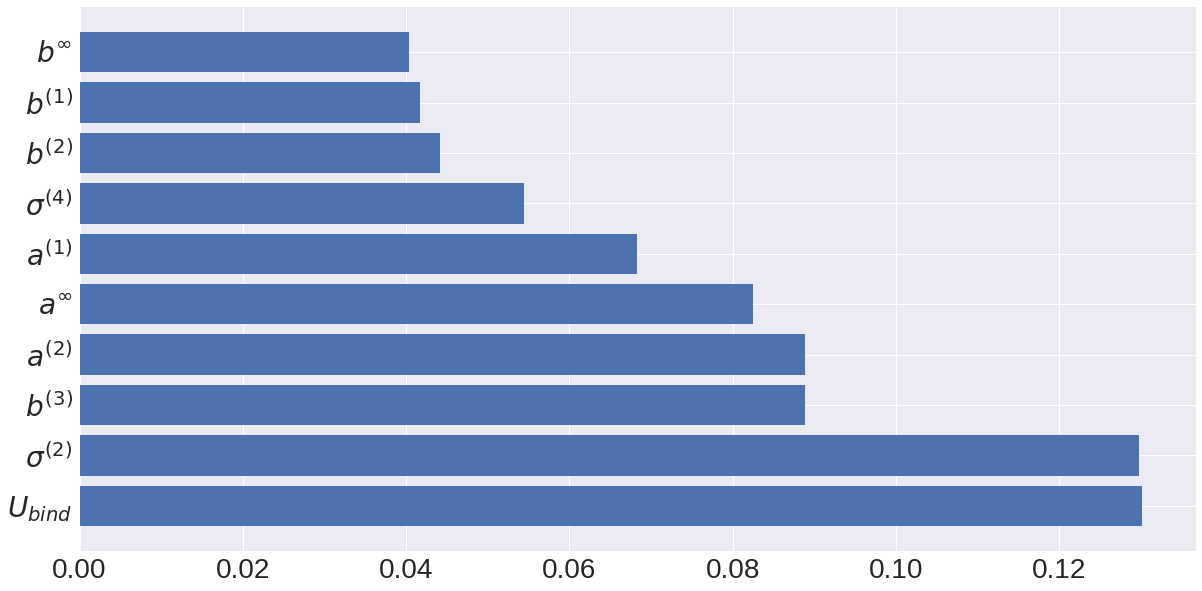

In [46]:
features_with_importances_weights = pd.DataFrame({'features':X.columns, 'importancies':model1_sample_wights['model'].feature_importances_}).sort_values(by='importancies', ascending=False)
plt.barh(features_with_importances_weights[:10]['features'], features_with_importances_weights[:10]['importancies'])
plt.gca().set_yticklabels(feature_titles[features_with_importances_weights[:10]['features']].values)

In [47]:
mean_squared_error(Y, Predict_weights,squared=False)

0.07857504587229747

# can I predict some specific tcp phase ?

In [48]:
BOP[BOP.index.str.contains('delta')]

,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_SIGMA_0,NSC_SIGMA_1,NSC_SIGMA_2,NSC_SIGMA_3,...,NSC_bn_0,NSC_bn_1,NSC_bn_2,NSC_bn_3,NSC_bn_4,NSC_bn_5,NSC_bn_6,NSC_Ainf_0,NSC_Binf_0,NSC_U_bind
index,,,,,,,,,,,,,,,,,,,,,
Al.delta.FM,0.0,0.467384,-0.076302,0.395657,-0.140581,0.420918,1.0,0.133856,0.150018,-0.105612,...,0.0,0.680500,0.579207,0.652162,1.0,0.0,0.0,-0.085312,0.639462,-167.084444
Re.delta.FM,0.0,0.630265,-0.116404,0.728640,-0.295384,1.061696,1.0,0.132063,0.131795,-0.101187,...,0.0,0.790212,0.684591,0.764087,1.0,0.0,0.0,-0.098539,0.748536,-193.475730
W.delta.FM,0.0,0.492327,-0.082082,0.440198,-0.159897,0.494974,1.0,0.133411,0.145984,-0.105113,...,0.0,0.698415,0.596603,0.670795,1.0,0.0,0.0,-0.087412,0.657451,-171.379007


## Helper Function

## for example fcc:

I will only use the TCP phases for the training.

In [49]:
def PredictPhase(
    features,
    _DATA,
    phase='C15',
    trainsplit = 0.1 ,
    _model=model1,
    _sample_weights = None,
    name=None,
    dotheplot = True,
    problemth = None
) :
    """this function train on the rest of the dataset + a protion of the target phase
    
    Paramaeters
    ===========
    features: list of features to use at training
    _DATA: dataset
    phase: target phase
    trainsplit: split of target phase to add on train set
    _model: regression model
    _sample_weights: sample weights
    dotheplot: weather to make the plot or not.
    plrblemth: threshold to get problematic phases
    
    Returns:
    trainsplit: fraction of target phase used at train (just for convenience.)
    r2scoretcp: r2score over test part of split.
    """
#    DATA = pd.concat((FEATURES, TARGET), axis=1)
    phase_index = _DATA.index.str.contains(phase)
    PXTRAIN, PXTEST, PYTRAIN, PYTEST = train_test_split(
        _DATA.loc[phase_index][features],
        _DATA.loc[phase_index]['EF'],
        train_size = trainsplit,
        shuffle = True,
        random_state=1234
    )
    XTRAIN = _DATA.drop(index=PYTEST.index)[features]#, columns=['EF'])
    YTRAIN = _DATA['EF'][XTRAIN.index]
    if any(_sample_weights != None):
        TRAINW = _sample_weights.loc[XTRAIN.index]
        if isinstance(_model, sklearn.pipeline.Pipeline):
            fitparams = {_model.steps[-1][0]+'__'+'sample_weight': TRAINW}
        else:
            fitparams = {'sample_weight': TRAINW}
    else: 
        fitparams={}
    
    _model.fit(XTRAIN,YTRAIN, **fitparams)
    YPREDICT = _model.predict(XTRAIN)
    TCPPREDICT = _model.predict(PXTEST)
    TCPERRORS = TCPPREDICT - PYTEST
    ERRORS = YPREDICT - YTRAIN
    RMSE_full = mean_squared_error(YTRAIN, YPREDICT, squared=False)
    RMSE_tcp = mean_squared_error(PYTEST,TCPPREDICT, squared=False)
    rmsestring_full = 'RMSE score = {:.3f}'.format(RMSE_full)
    rmsestring_tcp = 'RMSE score = {:.3f}'.format(RMSE_tcp)
    if dotheplot:
        fig,ax = plt.subplots(1,2)
        ax[0].hist(np.abs(TCPERRORS), density=True, bins = 100, color='red', label='Predict on '+phase+' '+rmsestring_tcp)
        ax[0].hist(np.abs(ERRORS), density = True, bins = 100,alpha=.5, label = 'The rest of compounds '+rmsestring_full)
        ax[0].set_xlabel('$|E_f ^{train} - E_f ^{predict}|$  ')
        ax[0].set_ylabel('density count')
        ax[0].legend()

        ax[1].plot(YPREDICT,YTRAIN,'or',label='The rest of the systems')
        ax[1].plot(TCPPREDICT,PYTEST,'ok',alpha=0.5, label='prediction on '+phase)
        ax[1].set_xlabel('Train Values')
        ax[1].set_ylabel('Predicted Values')
        ax[1].plot(DATA['EF'],DATA['EF'],'g',label='data')
        ax[1].legend()
        if name == None:
            tit = fig.suptitle(type(_model))
        else:
            tit = fig.suptitle(name)
        fig.tight_layout()
    if problemth is not None:
        PROBLEMATIC = PYTEST[np.abs(TCPERRORS)>problemth]
        # I still need to get the position where to get a banner with the name of the problematic sample
        
    return trainsplit, RMSE_tcp
        

# split, r2 = PredictPhase(Bestfeats, DATA, phase='C15', trainsplit=0.5,  _sample_weights=Classes['Weights'], problemth=0.3)

Stored 'list_BOP' (list)


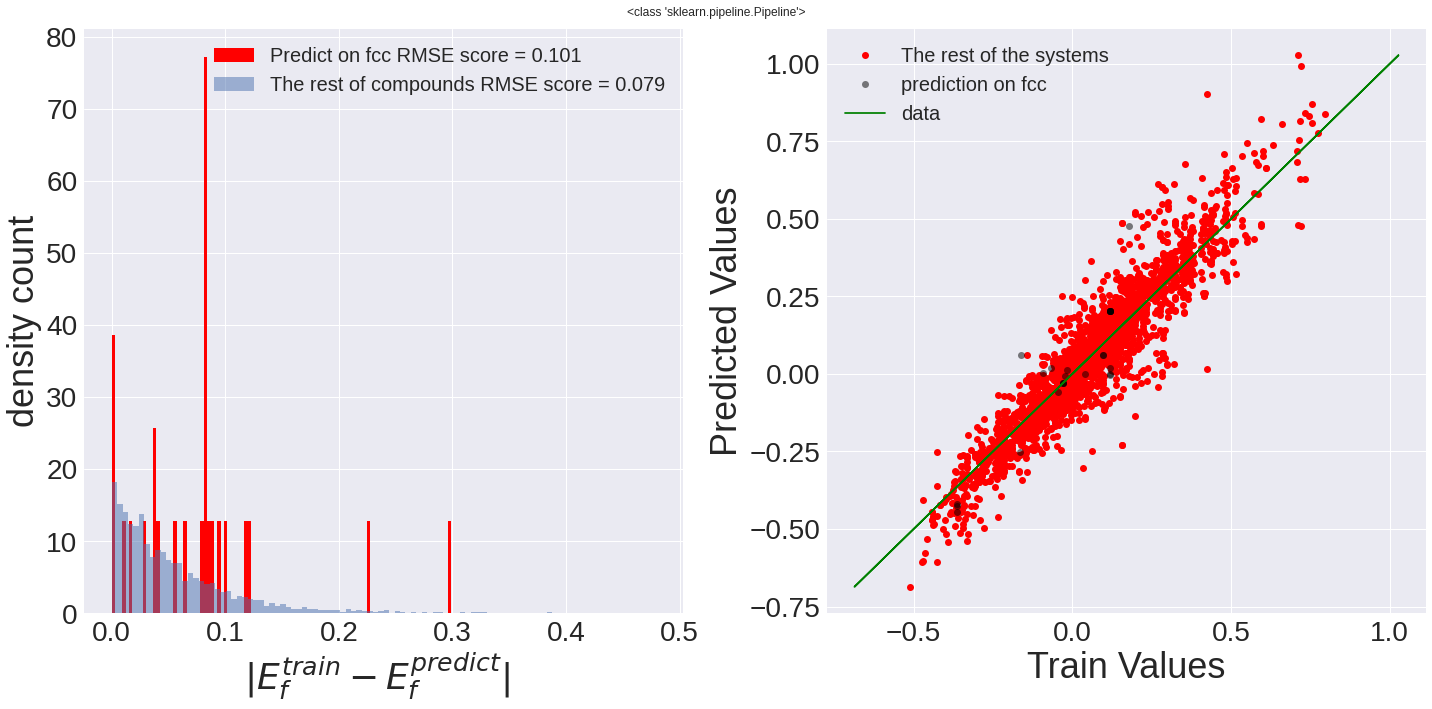

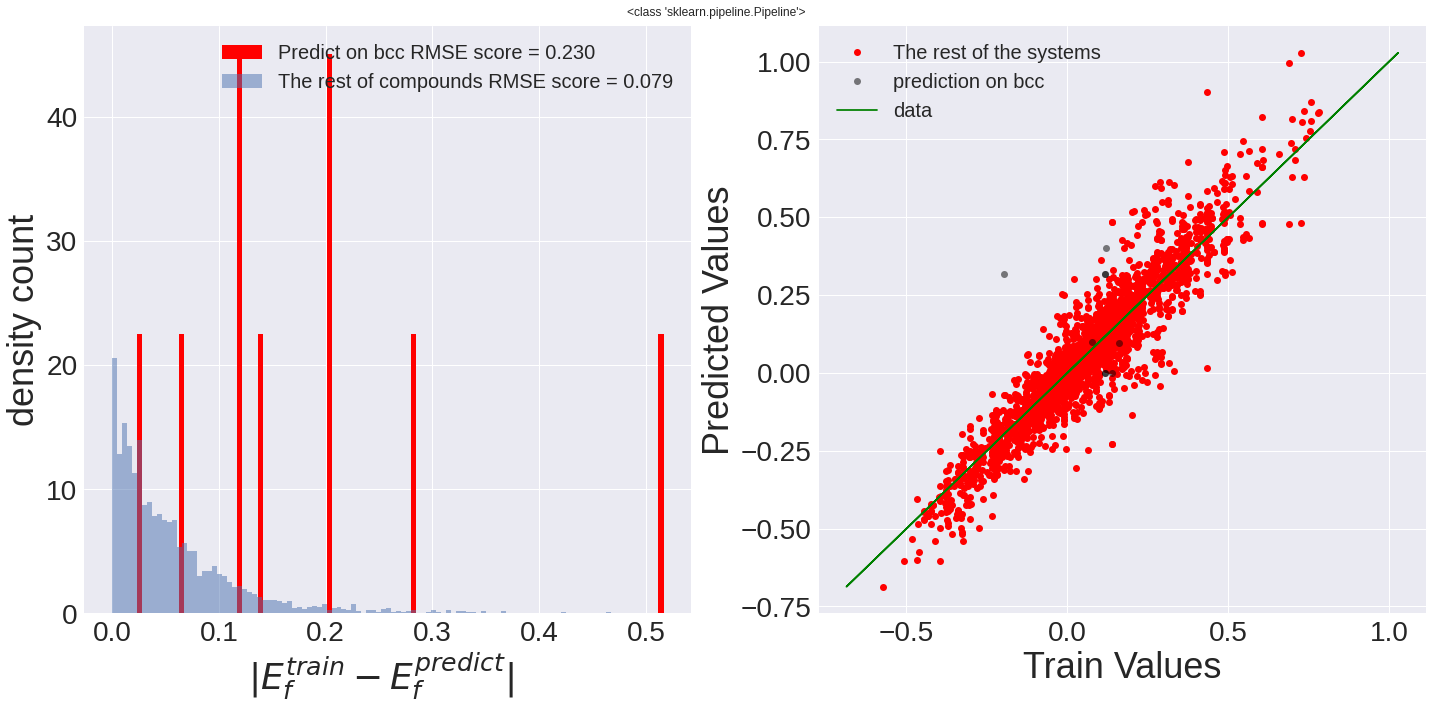

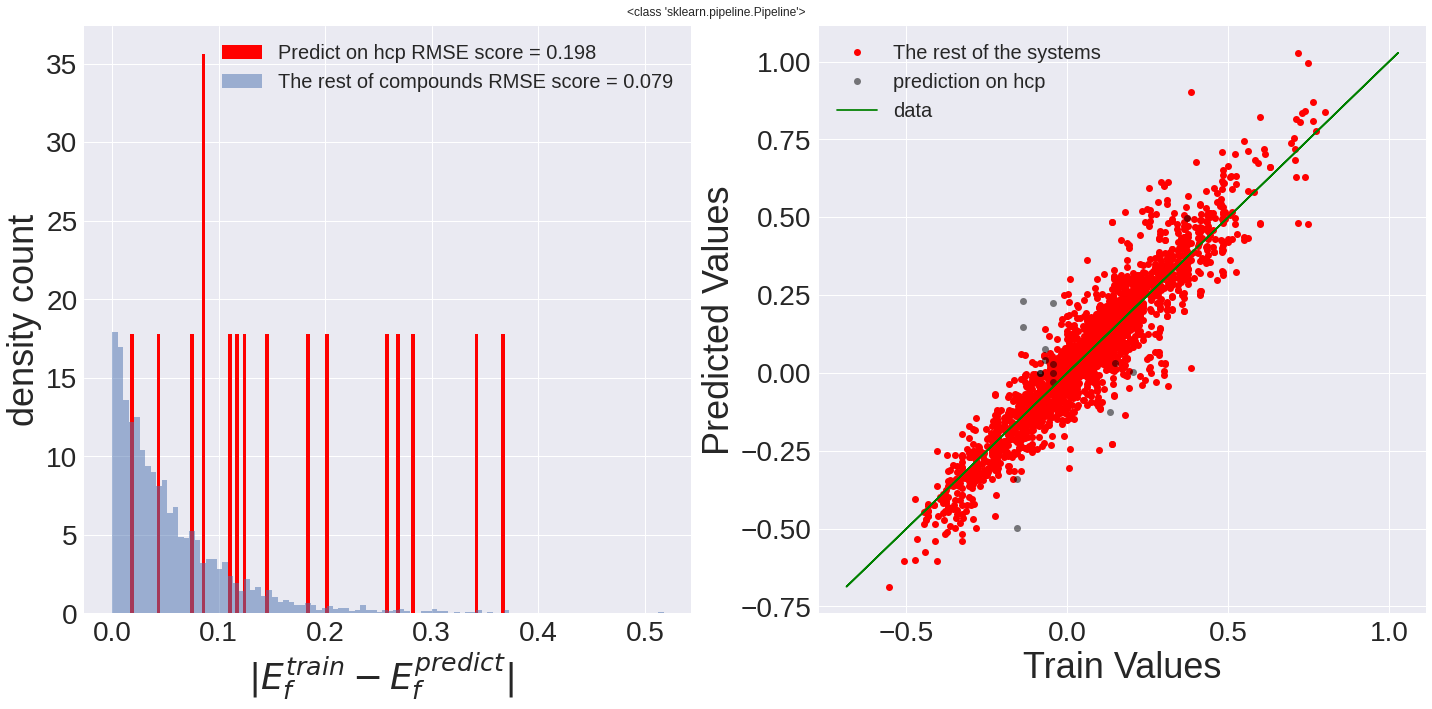

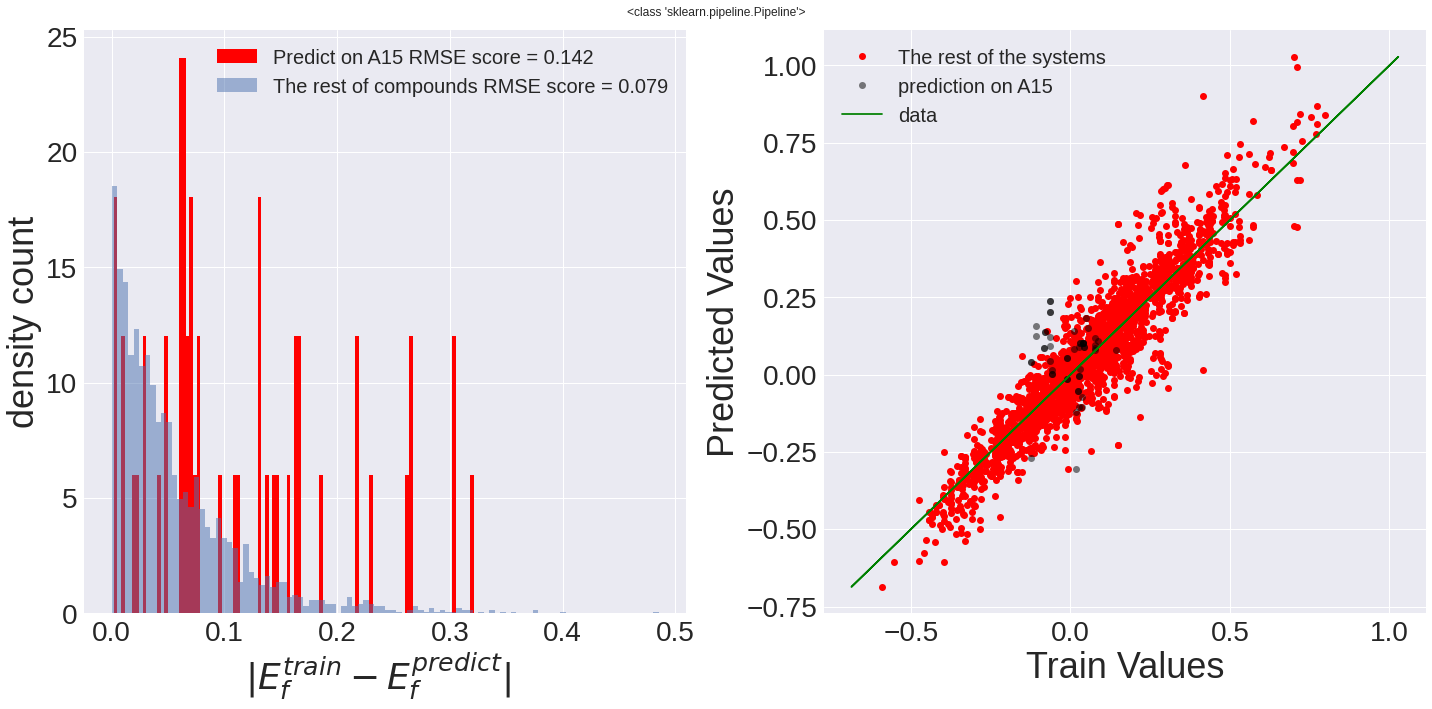

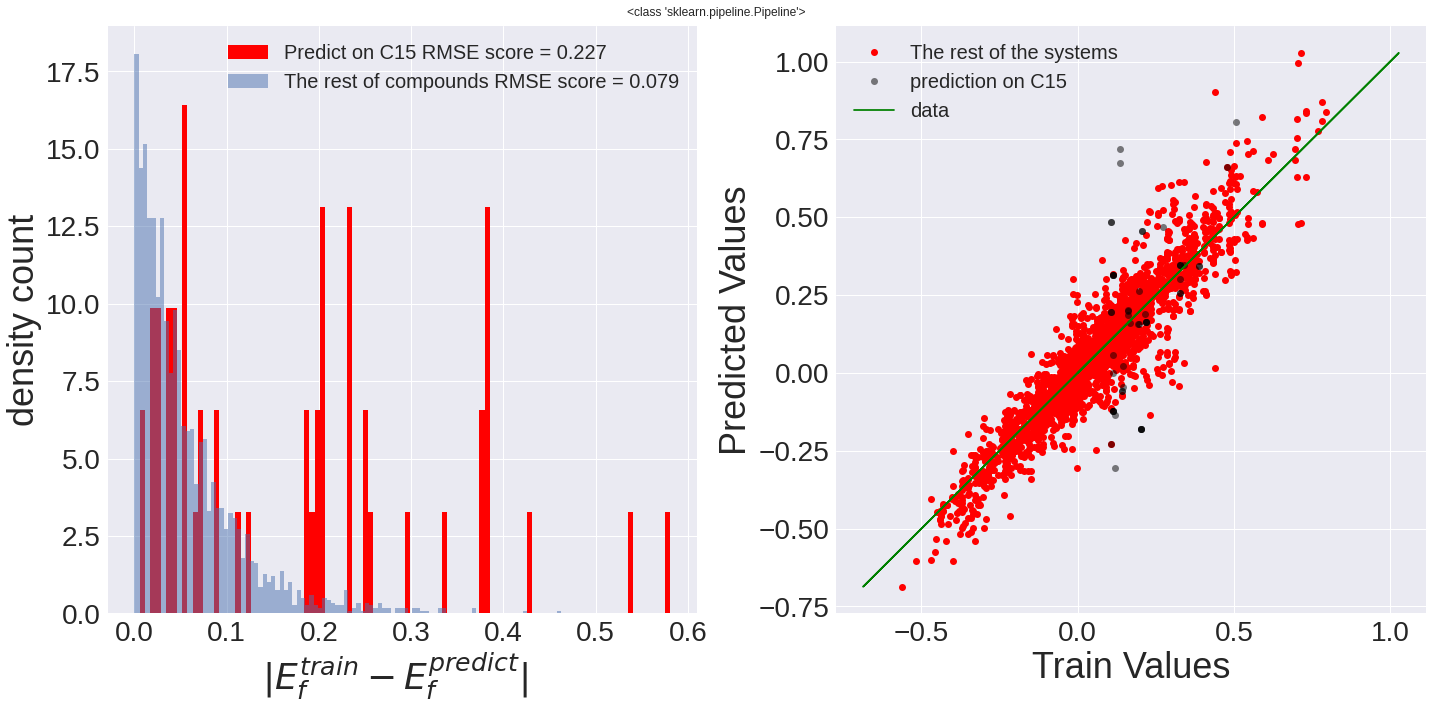

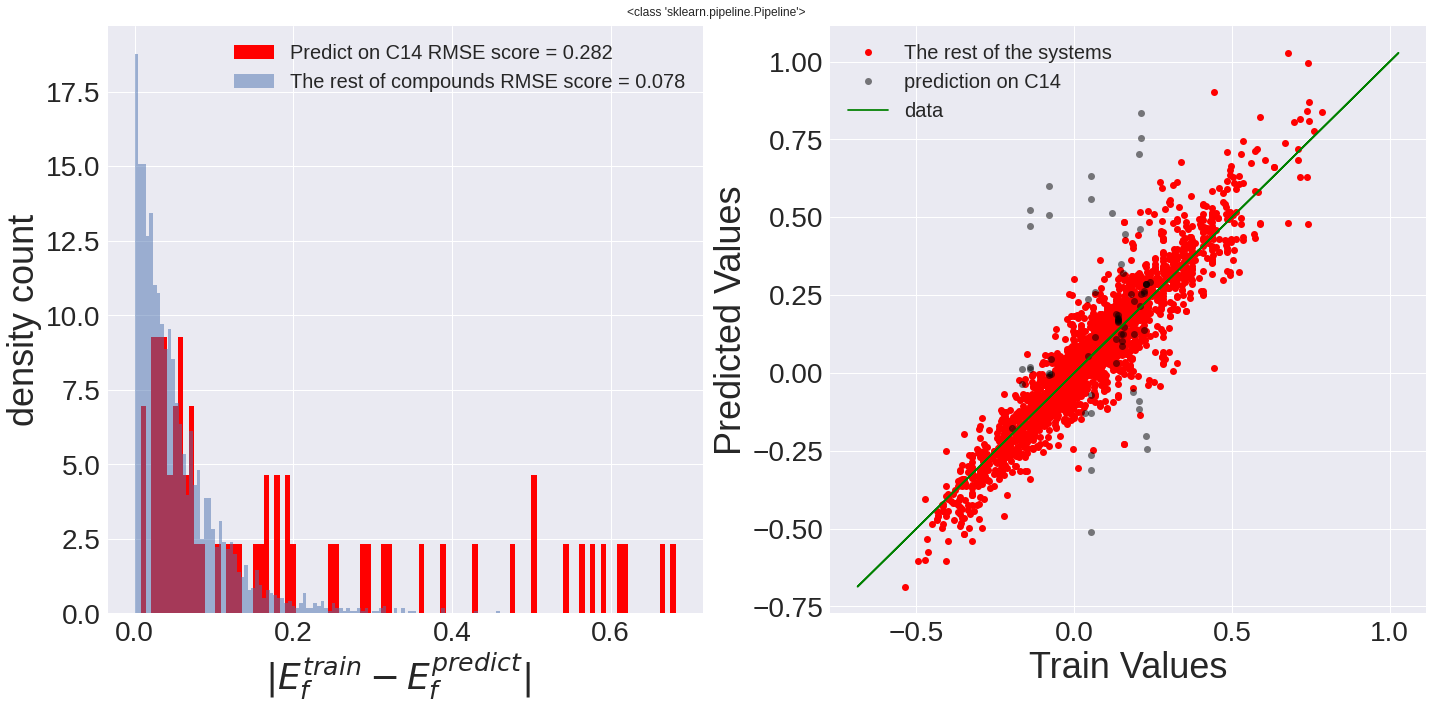

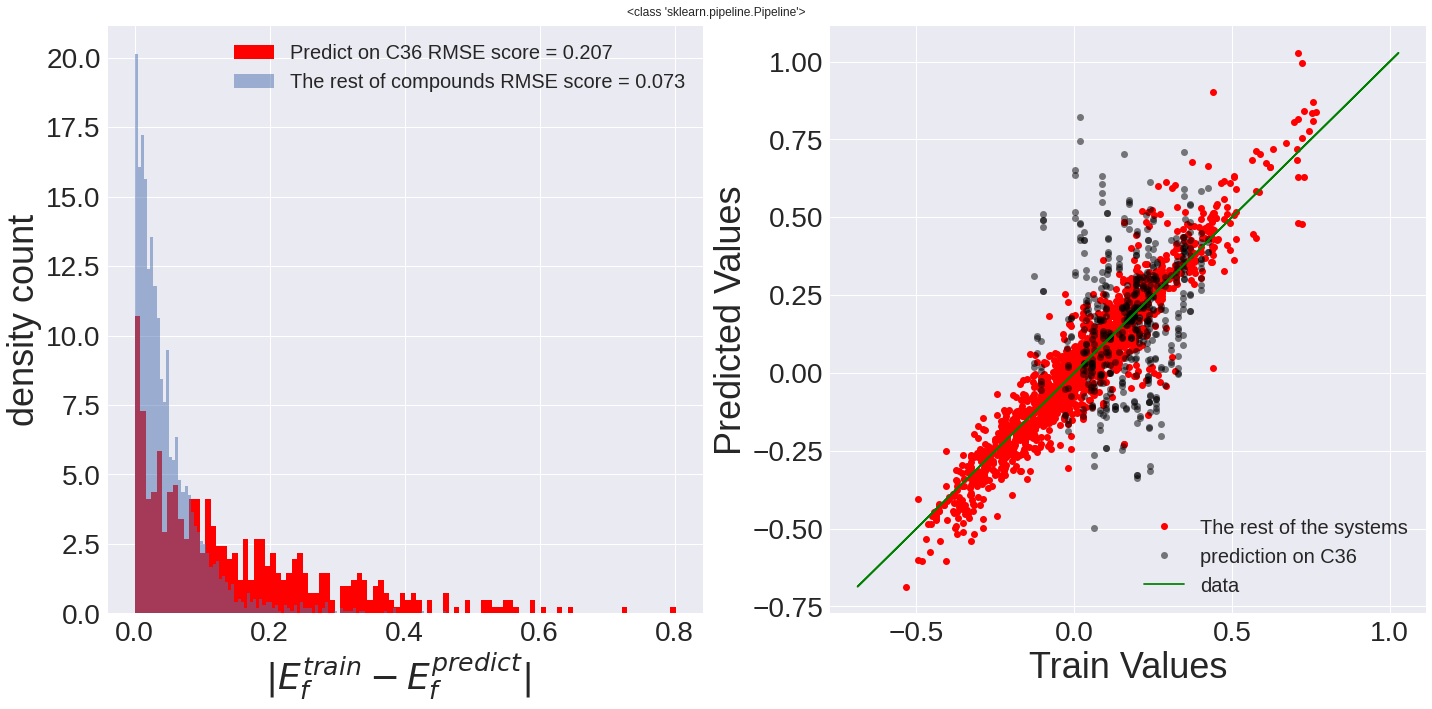

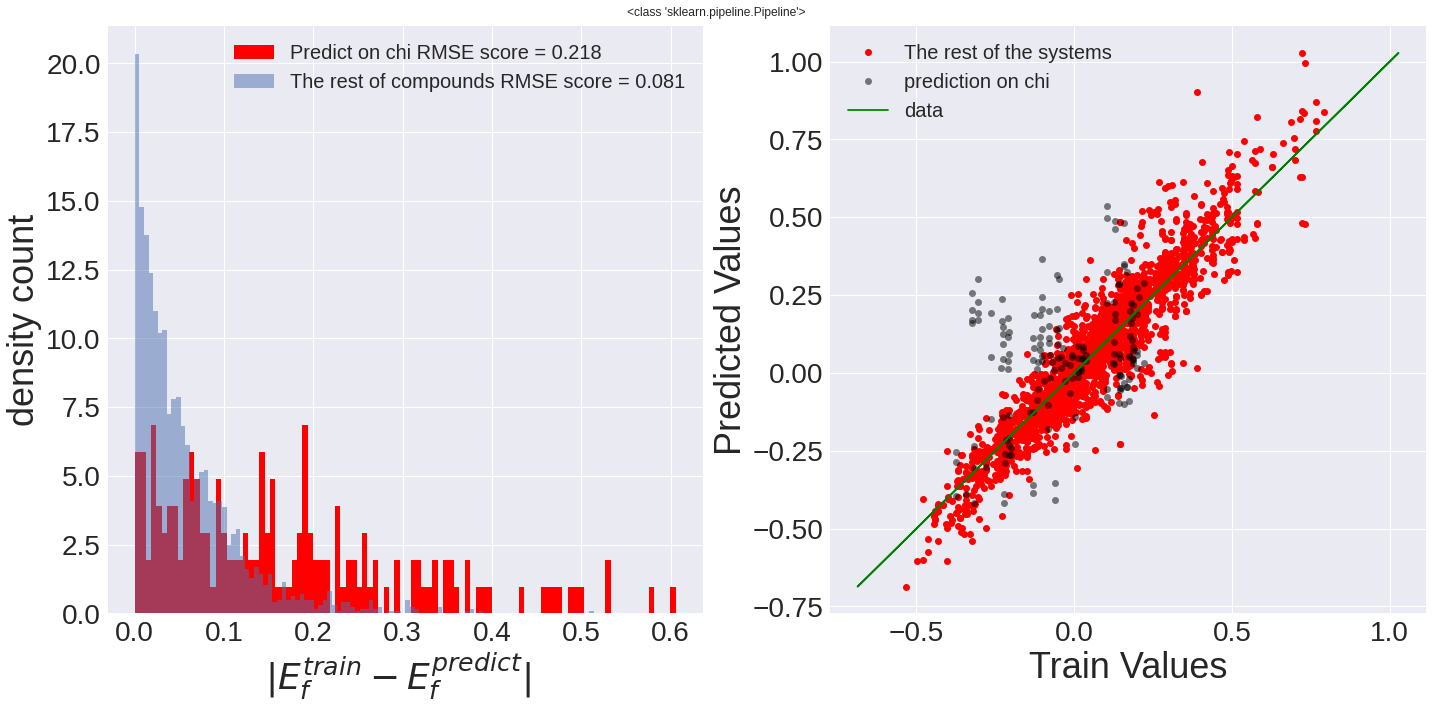

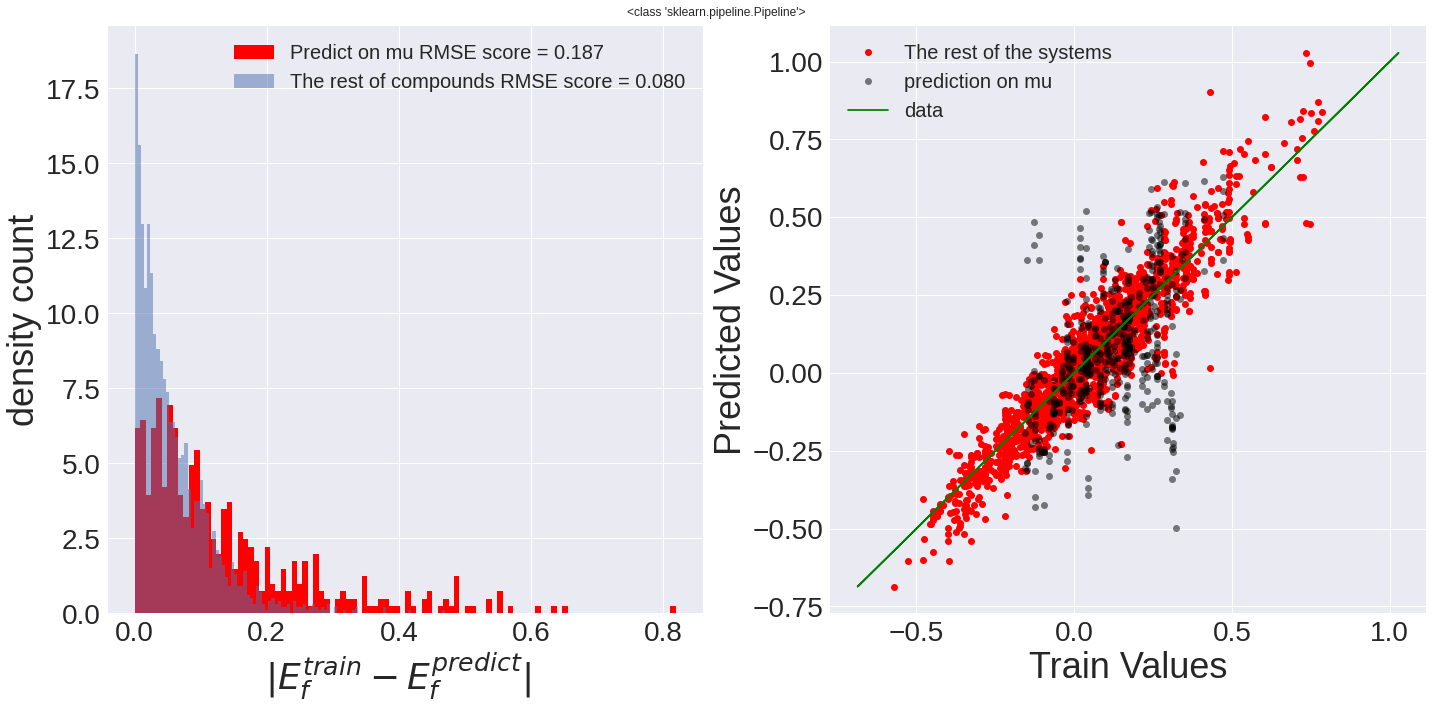

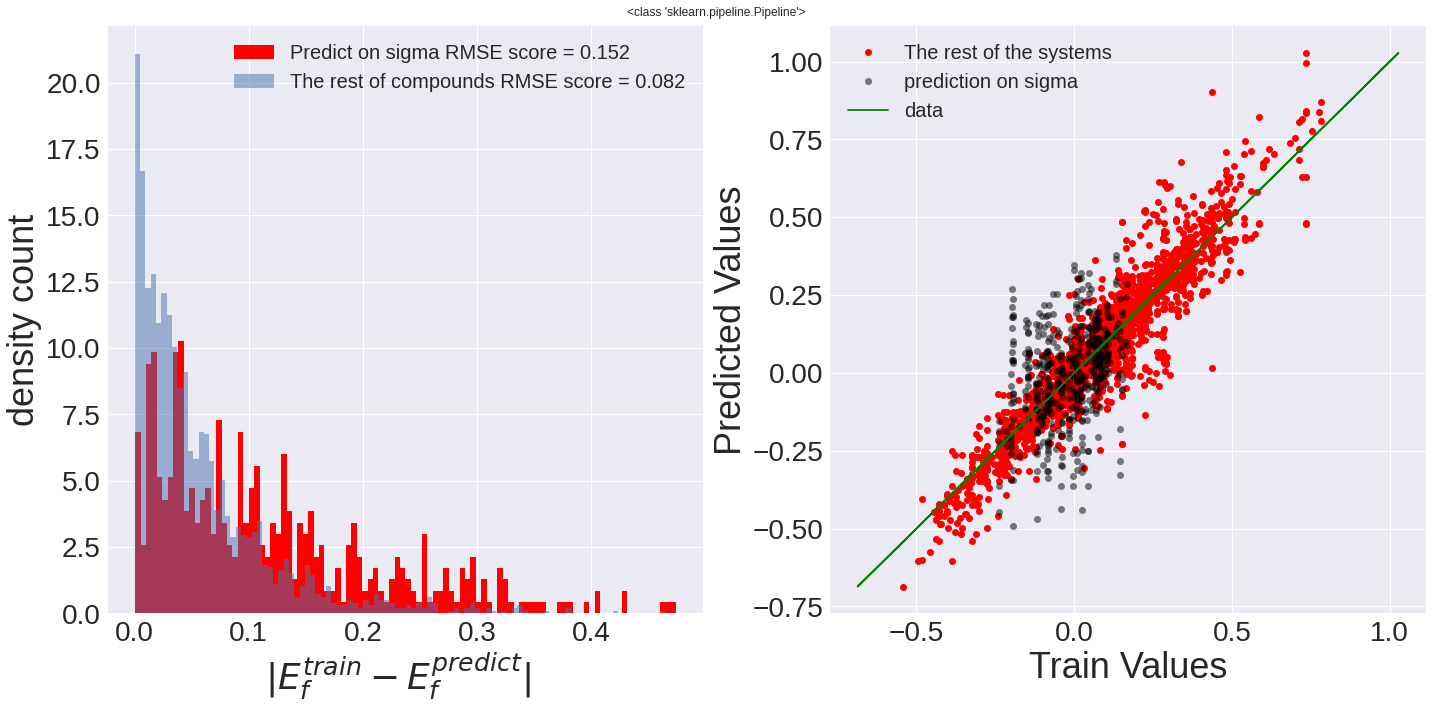

In [50]:
Interesting_classes = ['fcc', 'bcc', 'hcp', 'A15', 'C15', 'C14', 'C36', 'chi', 'mu', 'sigma']

list_BOP  = []
for p, phase in enumerate(Interesting_classes):
    list_BOP.append(
        PredictPhase(features_with_importances_weights[:10]['features'], DATA, phase=phase, _sample_weights=Classes['Weights'])
    )
#        list_BOP.append( test(features_with_importances_weights[:10]['features'], DATA, phase=phase, _sample_weights=Classes['Weights'], name='Random Forest Regressor Weighted') )
%store list_BOP

In [51]:
def incsplit(bestlist, alllist, phase='fcc', dotheplot=True):
    fitfull = []
    fitbest = []
    trainsplit = [0.1, 0.2, 0.3, 0.4,0.5, 0.6, 0.7, 0.8]
    progress = tqdm_notebook(trainsplit, ncols = 800, ascii = True)
    for splitsize in progress:
        dum, rmseful = PredictPhase(alllist, DATA, phase=phase,
                                  trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                  dotheplot=False)
        fitfull.append(rmseful)
        dum, rmsebest = PredictPhase(bestlist, DATA, phase=phase,
                                   trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                   dotheplot=False)
        fitbest.append(rmsebest)
    if dotheplot:
        fig, ax = plt.subplots()
        ax.plot(trainsplit, fitfull, '--o', label = 'full features')
        ax.plot(trainsplit, fitbest, '--o', label = 'only best features')
        ax.set_ylabel('RMSE on predictions for {:s}'.format(phase), fontsize=36)
        ax.set_xlabel('split fraction on target phase', fontsize=36)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=36)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=36)
        ax.legend()
        fig.savefig(f'graphs/incsplits_{phase}.pdf')
    return trainsplit, fitbest, fitfull

In [52]:
performances  = {}
Interesting_classes = ['A15', 'C15', 'C14', 'C36', 'chi', 'mu', 'sigma']

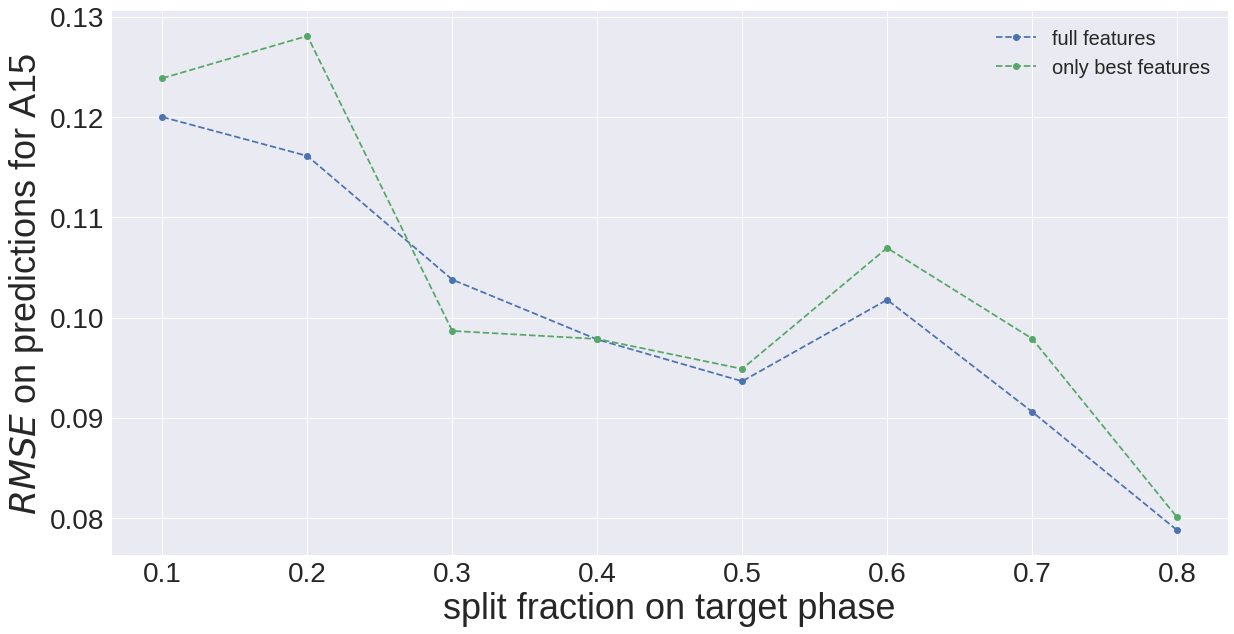

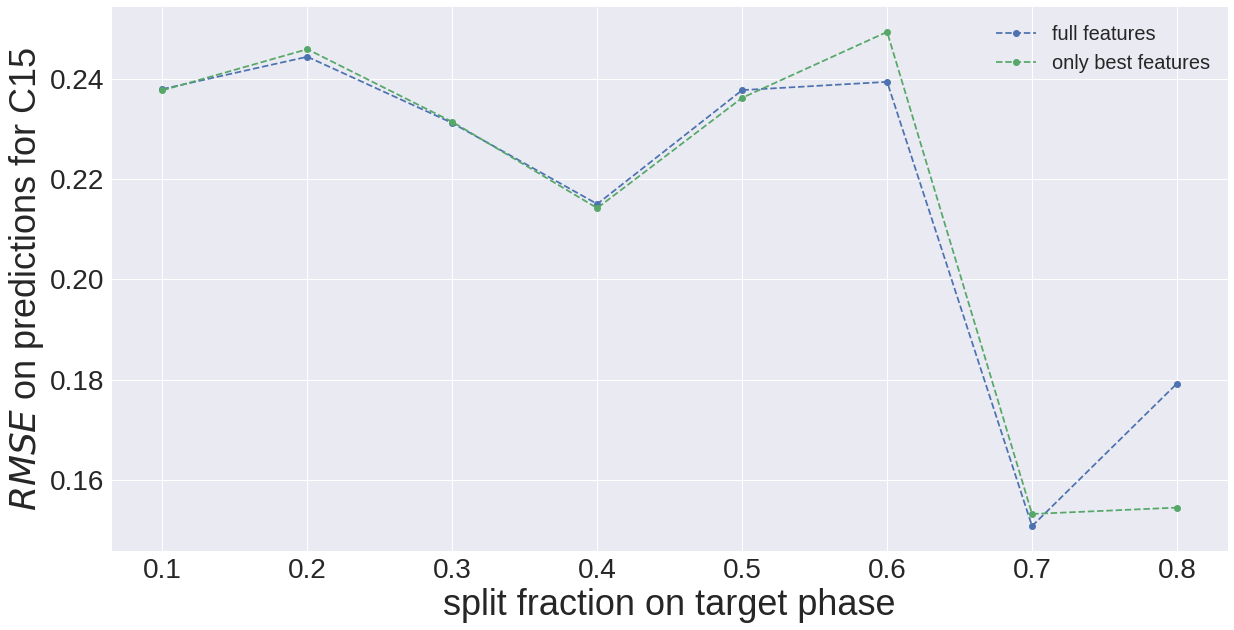

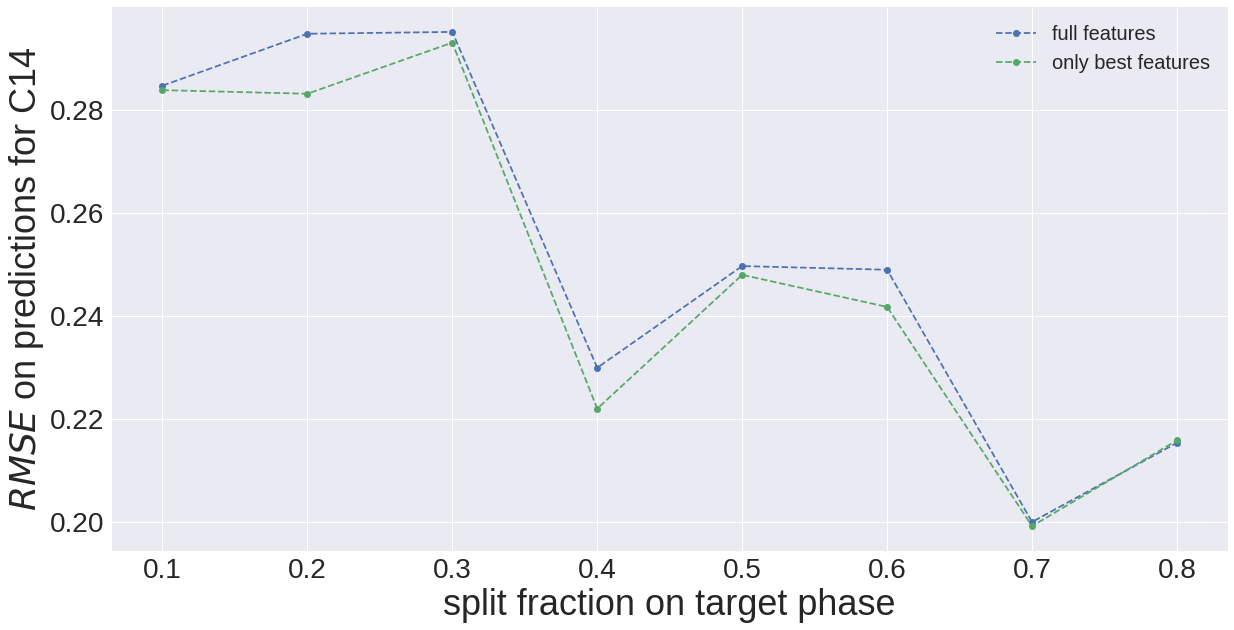

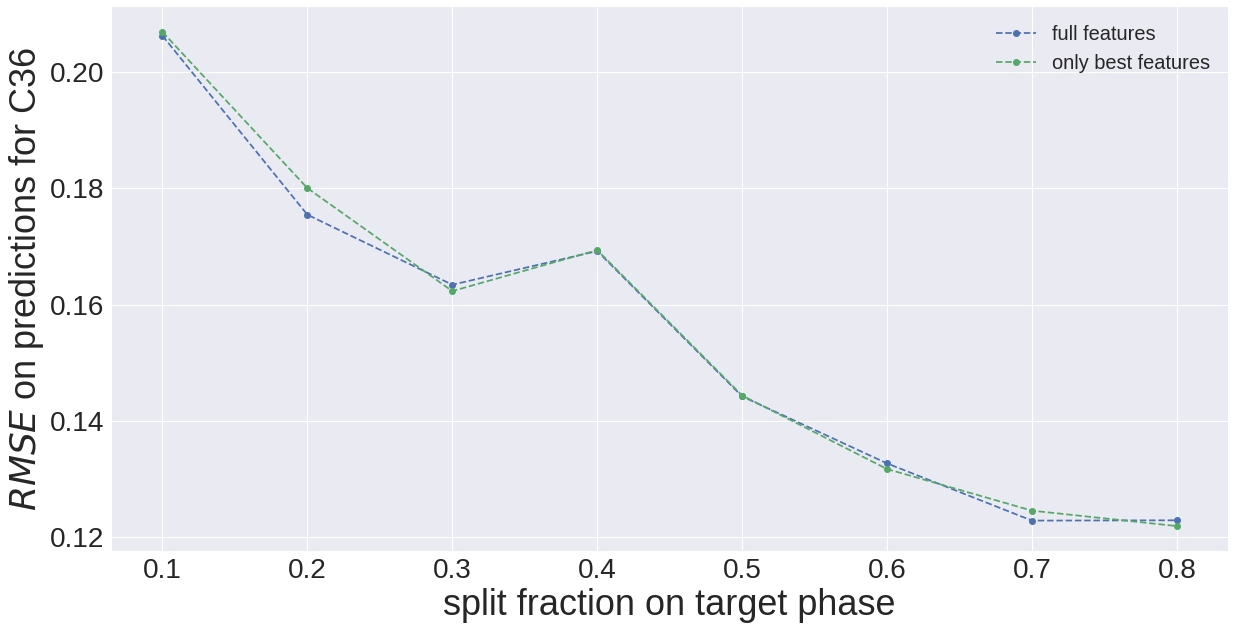

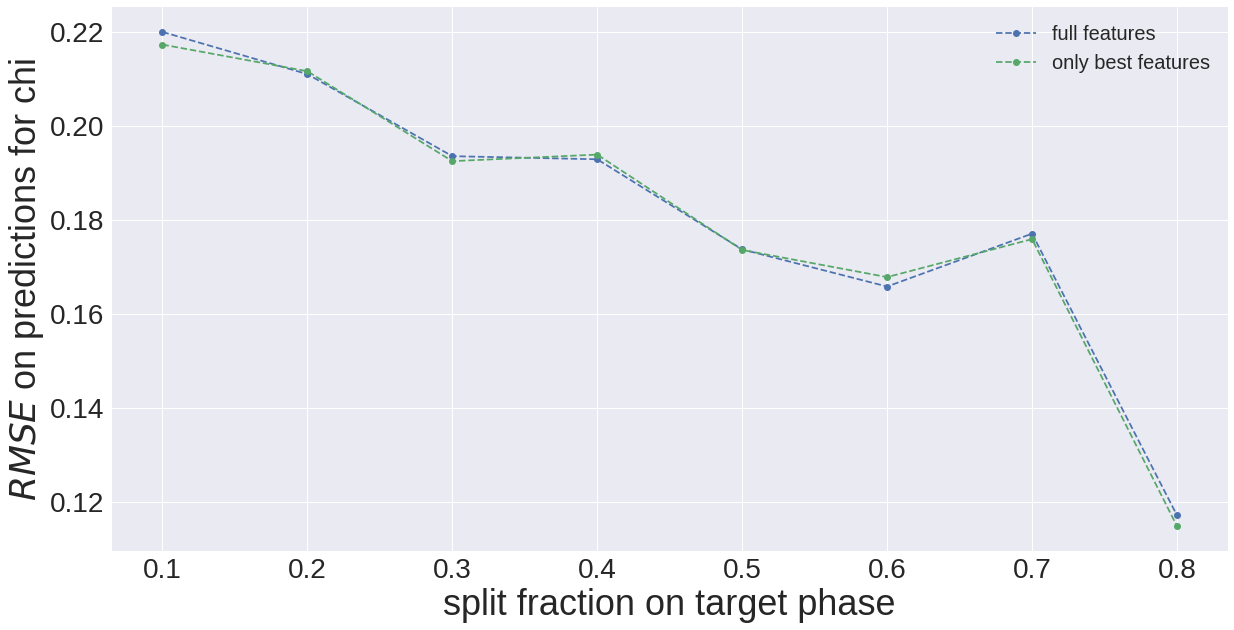

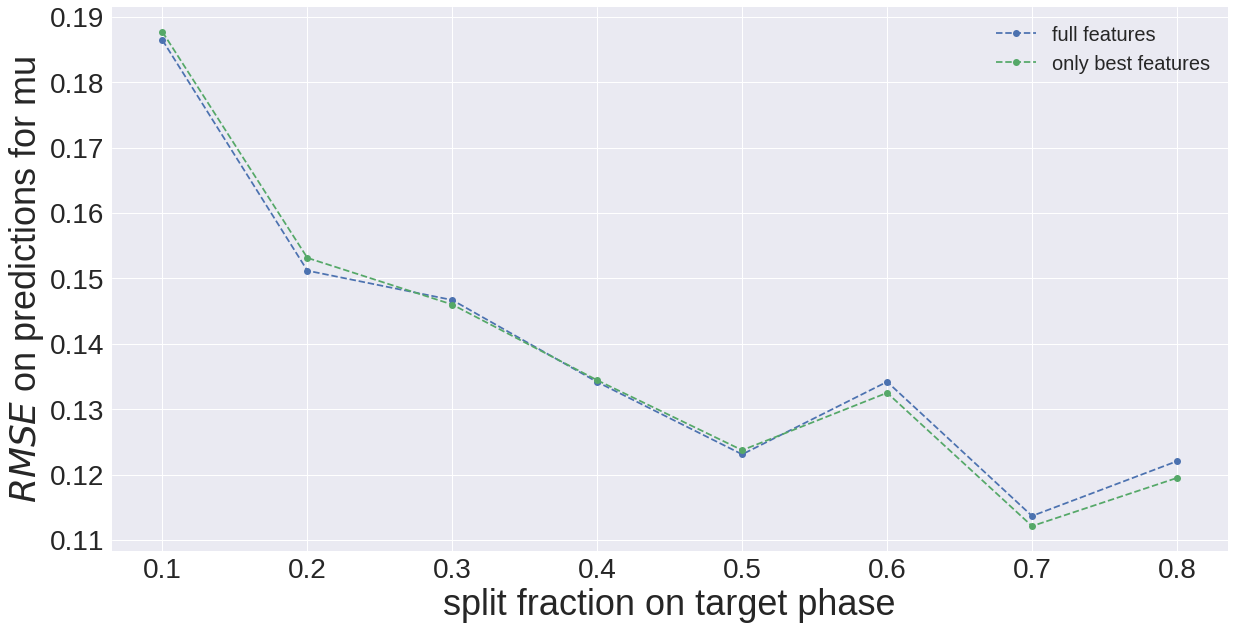

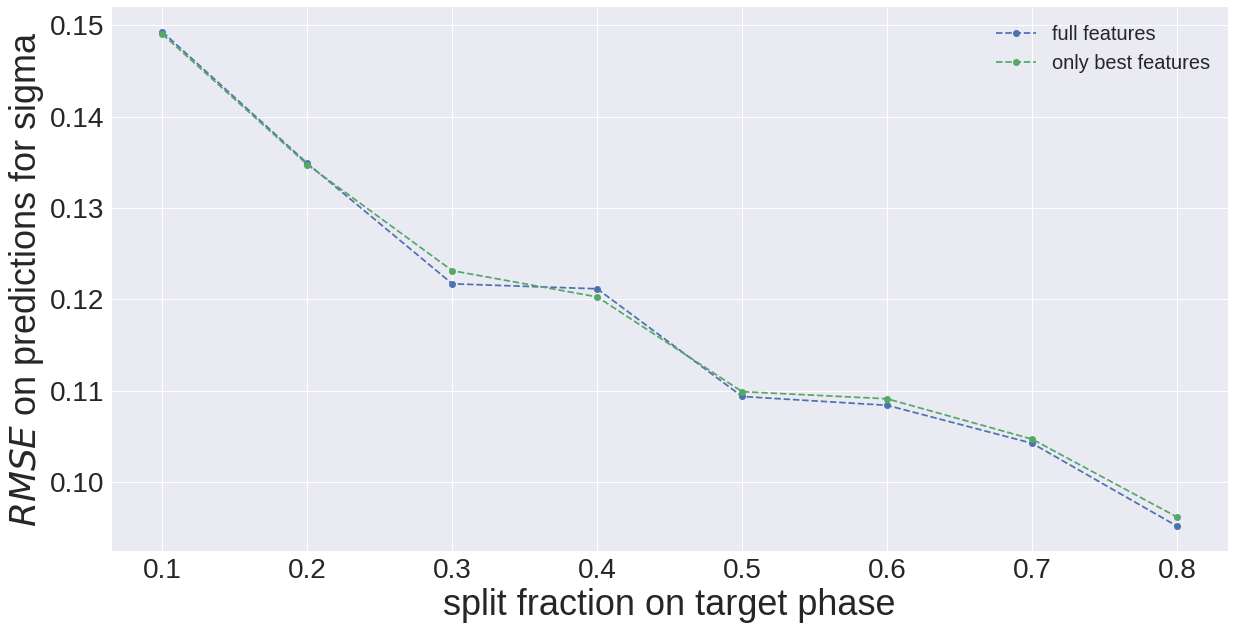

In [54]:
for p, phase in enumerate(Interesting_classes):
    if phase not in performances:
        splits, scoresbest, scorefull = incsplit(
            features_with_importances_weights[
                features_with_importances_weights['importancies']>0.02
            ]['features'],
            features_with_importances_weights['features'],
            phase=phase
        )
        performances[phase] = {'splits': splits, 'scoresbest': scoresbest, 'scoresfull':scorefull }
    else:
        fig, ax = plt.subplots()
        ax.plot(performances[phase]['splits'], performances[phase]['scoresfull'], '--o', label = 'full features')
        ax.plot(performances[phase]['splits'], performances[phase]['scoresbest'], '--o', label = 'only best features')
        ax.set_ylabel('$RMSE$ on predictions for {:s}'.format(phase))
        ax.set_xlabel('split fraction on target phase')
        ax.legend()
        fig.show()
        fig.savefig(f'graphs/canonical_incsplits_{phase}.pdf')

In [55]:
performances_canonical = performances
%store performances_canonical

Stored 'performances_canonical' (dict)
